# Hybrid Lorentz-ParT MAE for JetClass
This notebook documents a GSoC 2026 pipeline for jet classification using a hybrid ParT + Lorentz model with MAE pretraining.
Focus: clean data flow, stable training, and physics-aware evaluation.

## 1. Motivation
Jet tagging at the LHC benefits from models that capture both particle interactions and Lorentz structure.
This project combines ParT and Lorentz-inspired blocks, then uses MAE pretraining to improve downstream classification.

## 2. Setup
Imports, reproducibility controls, and runtime configuration are defined below.

In [1]:
import os, math, time, json, random, warnings, copy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

try:
    import uproot
    import awkward as ak
    HAS_ROOT = True
except ImportError:
    HAS_ROOT = False


## 2b. Speed and Regularization Helpers
This section adds optional speed optimizations and regularization utilities used in training.

In [2]:
                                                                                                                                                   
from contextlib import nullcontext

def maybe_compile(model):
    if not hasattr(torch, 'compile'):
        print('[INFO] torch.compile not available; using eager mode.')
        return model

    has_triton = False
    try:
        import triton              
        has_triton = True
    except Exception:
        has_triton = False

    if (not torch.cuda.is_available()) or (not has_triton):
        print('[INFO] No working Triton backend; using eager mode.')
        return model

    try:
        import torch._dynamo as dynamo
        dynamo.config.suppress_errors = True
        return torch.compile(model, mode='reduce-overhead')
    except Exception as ex:
        print(f'[WARN] torch.compile unavailable: {ex}')
        return model

def amp_ctx(device):
    if str(device).startswith('cuda'):
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()

                                                                                                                                              
def vicreg_variance_term(z: torch.Tensor, eps: float = 1e-4) -> torch.Tensor:
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(torch.relu(1.0 - std))

def vicreg_covariance_term(z: torch.Tensor) -> torch.Tensor:
    z = z - z.mean(dim=0, keepdim=True)
    n, d = z.shape
    cov = (z.T @ z) / max(n - 1, 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return off_diag.pow(2).sum() / d

def vicreg_loss(z: torch.Tensor,
                lambda_var: float = 25.0,
                lambda_cov: float = 1.0) -> torch.Tensor:
    l_var = vicreg_variance_term(z)
    l_cov = vicreg_covariance_term(z)
    return lambda_var * l_var + lambda_cov * l_cov

print('Speed helpers and VICReg loaded.')
print(f'  torch.compile available : {hasattr(torch, "compile")}')
print(f'  TF32 matmul             : {torch.backends.cuda.matmul.allow_tf32}')
print(f'  cuDNN benchmark         : {torch.backends.cudnn.benchmark}')


Speed helpers and VICReg loaded.
  torch.compile available : True
  TF32 matmul             : False
  cuDNN benchmark         : False


In [3]:
@dataclass
class Config:
    DATA_ROOT: str = '../datasets/JetClass'
    MAX_PARTICLES: int = 50                                          
                                                                      
                                                                                             
    NUM_CLASSES: int = 10

                                                                                                                                                                 
                                                                        
                                                                   
                                                                       
    BATCH_SIZE: int = 128
    NUM_WORKERS: int = 0
    PRETRAIN_EPOCHS: int = 20                                                                 
    FINETUNE_EPOCHS: int = 35                                                               
    LEARNING_RATE: float = 3e-4

                                                                           
                                                                            
    WEIGHT_DECAY: float = 0.01
    MASK_RATIO: float = 0.4

                                                                                                                                                                               
    WARMUP_EPOCHS: int = 3
    LABEL_SMOOTHING: float = 0.1
    USE_BIASED_MASK: bool = True

                                                                          
                                                                          
                                                                       
                                                                           
    BACKBONE_LR_FACTOR: float = 0.3

                                                                                                                                                                   
    KINEMATIC_LOG_FEATURES: Tuple[str, ...] = ('px', 'py', 'pz', 'E', 'pt', 'deltaR')
                                                                                           
    MASS_TARGET_NORMALIZE: bool = True
    MASS_NORM_EPS: float = 1e-6
    GATE_REG_WEIGHT: float = 0.02                                                  

                                                                            
    USE_JEPA_PRETRAIN: bool = False                                                        
                                                                                       
                                                                 
    JEPA_WEIGHT: float = 0.5
    JEPA_EMA_DECAY: float = 0.996

                                                                  
    ATTN_INTERACTION_GATE_STRENGTH: float = 1.0

                                               
    USE_PHYSICS_RECO_WEIGHTING: bool = True
    RECO_WEIGHT_PT: float = 1.0
    RECO_WEIGHT_ETA: float = 0.5
    RECO_WEIGHT_PHI: float = 0.3
    RECO_WEIGHT_E: float = 1.0
    RECO_WEIGHT_DEFAULT: float = 0.7

    USE_AUX_MASS: bool = True
    USE_CLASS_WEIGHTS: bool = True
    USE_MIXED_PRECISION: bool = True
    QUICK_DEMO_MODE: bool = False
    QUICK_MAX_EVENTS_PER_FILE: int = 1000
    FULL_MAX_EVENTS_PER_FILE: Optional[int] = 2500

                                                                        
                                                                         
                                                                         
                                                                      
                                                                             
                                                                           
                                                                                
    SAMPLE_SIZE_LIMIT: int = 100000
    ENFORCE_STRICT_100K_WHEN_AVAILABLE: bool = True
    SAMPLING_SEED: Optional[int] = 42

    NUM_TRAIN_FILES: Optional[int] = None
    NUM_VAL_FILES: Optional[int] = None
    NUM_TEST_FILES: Optional[int] = None

                                                                  
                                                                             
                                                
                                                                  
                                                                               
                                                                         
                                                                        
    PER_PARTICLE_FEATURES: Tuple[str, ...] = (
                                                 
        'px', 'py', 'pz', 'E',
                                                                        
                                                                          
                                                                            
                                                                          
                                                                           
        'pt', 'deta', 'dphi', 'deltaR',
                                                                         
        'charge',
        'isChargedHadron', 'isNeutralHadron', 'isPhoton',
        'isElectron', 'isMuon',
                                                                                 
        'd0val', 'd0err', 'dzval', 'dzerr',
        'valid_mask',
    )
    PAIRWISE_FEATURES: Tuple[str, ...] = ('lnDelta', 'lnkT', 'lnz', 'lnm2')
                                                                                     
    SCALE_FEATURES: Tuple[str, ...] = ('charge', 'd0val', 'd0err', 'dzval', 'dzerr')
                                                                   
                                                                      

                                                                                
                                                                               
    EMBED_DIM: int = 128
    NUM_HEADS: int = 8
    NUM_LAYERS_PART: int = 6              
    NUM_LAYERS_LORENTZ: int = 4           
    NUM_CLS_BLOCKS: int = 2                                                 
    MLP_RATIO: float = 4.0
    DROPOUT: float = 0.15                                                                      
    USE_TOKEN_GATE: bool = True
    USE_EVENT_GATE: bool = True

    W_RECO: float = 1.0
    W_CONS: float = 0.2
    W_CLASS: float = 1.0
    AUX_MASS_WEIGHT: float = 0.2

    GRAD_CLIP_NORM: float = 1.0
                                                                          
                                                                    
    EARLY_STOP_PATIENCE: int = 10
    SEED: int = 42

                                                                         
                                                                          
                                                                       
                                                                                
    CUDNN_BENCHMARK: bool = True

                                                                           
    SIGNAL_EFF_STANDARD: float = 0.50
    SIGNAL_EFF_HIGH:     float = 0.99

cfg = Config()
cfg

Config(DATA_ROOT='../datasets/JetClass', MAX_PARTICLES=50, NUM_CLASSES=10, BATCH_SIZE=128, NUM_WORKERS=0, PRETRAIN_EPOCHS=20, FINETUNE_EPOCHS=35, LEARNING_RATE=0.0003, WEIGHT_DECAY=0.01, MASK_RATIO=0.4, WARMUP_EPOCHS=3, LABEL_SMOOTHING=0.1, USE_BIASED_MASK=True, BACKBONE_LR_FACTOR=0.3, KINEMATIC_LOG_FEATURES=('px', 'py', 'pz', 'E', 'pt', 'deltaR'), MASS_TARGET_NORMALIZE=True, MASS_NORM_EPS=1e-06, GATE_REG_WEIGHT=0.02, USE_JEPA_PRETRAIN=False, JEPA_WEIGHT=0.5, JEPA_EMA_DECAY=0.996, ATTN_INTERACTION_GATE_STRENGTH=1.0, USE_PHYSICS_RECO_WEIGHTING=True, RECO_WEIGHT_PT=1.0, RECO_WEIGHT_ETA=0.5, RECO_WEIGHT_PHI=0.3, RECO_WEIGHT_E=1.0, RECO_WEIGHT_DEFAULT=0.7, USE_AUX_MASS=False, USE_CLASS_WEIGHTS=True, USE_MIXED_PRECISION=True, QUICK_DEMO_MODE=False, QUICK_MAX_EVENTS_PER_FILE=1000, FULL_MAX_EVENTS_PER_FILE=2500, SAMPLE_SIZE_LIMIT=100000, ENFORCE_STRICT_100K_WHEN_AVAILABLE=True, SAMPLING_SEED=42, NUM_TRAIN_FILES=None, NUM_VAL_FILES=None, NUM_TEST_FILES=None, PER_PARTICLE_FEATURES=('px', 'py', 

In [4]:
def seed_everything(seed: int, benchmark: bool = True) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
                                                                                 
                                                               
    torch.backends.cudnn.deterministic = not benchmark
    torch.backends.cudnn.benchmark = benchmark

seed_everything(cfg.SEED, benchmark=cfg.CUDNN_BENCHMARK)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = cfg.USE_MIXED_PRECISION and device.type == 'cuda'
print('Device:', device)
print('Mixed precision:', amp_enabled)
print('ROOT stack available:', HAS_ROOT)


Device: cuda
Mixed precision: True
ROOT stack available: True


## 3. Data Understanding
We inspect class balance, particle-level structure, and key dataset assumptions before modeling.

In [5]:
def resolve_data_root(user_path: str) -> Path:
    raw = Path(user_path)
    candidates = [
        raw,
        Path.cwd() / raw,
        Path.cwd().parent / raw,
        Path.cwd() / 'datasets' / 'JetClass',
        Path.cwd().parent / 'datasets' / 'JetClass',
    ]

    seen = set()
    for candidate in candidates:
        rp = candidate.resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if rp.exists() and rp.is_dir():
            return rp

    tried = '\n'.join([f' - {c.resolve()}' for c in candidates])
    raise FileNotFoundError('Could not locate JetClass data root. Tried:\n' + tried)

def discover_root_files(data_root: Path) -> List[Path]:
    return sorted(data_root.rglob('*.root')) if data_root.exists() else []

def infer_class_name(path: Path) -> str:
    return path.stem.split('_')[0]

data_root = resolve_data_root(cfg.DATA_ROOT)
cfg.DATA_ROOT = str(data_root)
files = discover_root_files(data_root)
print('CWD:', Path.cwd())
print('Data root:', data_root.resolve())
print('ROOT files found:', len(files))
for p in files[:8]:
    print(' -', p.name)

classes = sorted({infer_class_name(p) for p in files}) if files else []
print('Inferred classes:', classes)


CWD: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\notebook
Data root: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\datasets\JetClass
ROOT files found: 100
 - HToBB_000.root
 - HToBB_001.root
 - HToBB_002.root
 - HToBB_003.root
 - HToBB_004.root
 - HToBB_005.root
 - HToBB_006.root
 - HToBB_007.root
Inferred classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']


In [6]:
BRANCH_CANDIDATES = {
    'px':    ['part_px', 'px', 'PFCands_px', 'particle_px'],
    'py':    ['part_py', 'py', 'PFCands_py', 'particle_py'],
    'pz':    ['part_pz', 'pz', 'PFCands_pz', 'particle_pz'],
    'E':     ['part_energy', 'part_e', 'energy', 'E', 'PFCands_energy', 'particle_e'],
                                                                                    
                                                                                    
                                                                                        
    'pt':    ['part_pt', 'pt', 'PFCands_pt', 'particle_pt'],
    'deta':  ['part_deta', 'deta', 'part_eta'],                             
    'dphi':  ['part_dphi', 'dphi', 'part_phi'],                             
    'eta':   ['part_eta', 'eta', 'PFCands_eta', 'particle_eta'],                                    
    'phi':   ['part_phi', 'phi', 'PFCands_phi', 'particle_phi'],                                    
    'charge':['part_charge', 'charge', 'PFCands_charge', 'particle_charge'],
                                                                                       
    'isChargedHadron': ['part_isChargedHadron', 'isChargedHadron', 'PFCands_isChargedHadron'],
    'isNeutralHadron': ['part_isNeutralHadron', 'isNeutralHadron', 'PFCands_isNeutralHadron'],
    'isPhoton':        ['part_isPhoton',        'isPhoton',        'PFCands_isPhoton'],
    'isElectron':      ['part_isElectron',      'isElectron',      'PFCands_isElectron'],
    'isMuon':          ['part_isMuon',          'isMuon',          'PFCands_isMuon'],
                                                                                                    
    'd0val':  ['part_d0val',  'd0val',  'PFCands_d0val'],
    'd0err':  ['part_d0err',  'd0err',  'PFCands_d0err'],
    'dzval':  ['part_dzval',  'dzval',  'PFCands_dzval'],
    'dzerr':  ['part_dzerr',  'dzerr',  'PFCands_dzerr'],
}

def resolve_branches(available: List[str], candidates: Dict[str, List[str]]) -> Dict[str, Optional[str]]:
    lower = {a.lower(): a for a in available}
    out = {}
    for k, opts in candidates.items():
        hit = None
        for o in opts:
            if o in available:
                hit = o
                break
            if o.lower() in lower:
                hit = lower[o.lower()]
                break
        out[k] = hit
    return out

if HAS_ROOT and files:
    with uproot.open(files[0]) as f:
        tree_name = None
        for c in ['tree', 'events', 'Events', 'JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'keys'):
                    tree_name = k
                    break
        print('Selected tree:', tree_name)
        branches = [str(b) for b in f[tree_name].keys()]
        print('First branches:', branches[:30])
        resolved = resolve_branches(branches, BRANCH_CANDIDATES)
        print('Resolved map:', resolved)
        print('\nParticle-ID branches found:',
              {k: v for k, v in resolved.items()
               if k in ('isChargedHadron','isNeutralHadron','isPhoton','isElectron','isMuon')})
        print('Displacement branches found:',
              {k: v for k, v in resolved.items()
               if k in ('d0val','d0err','dzval','dzerr')})
else:
    print('No ROOT file available for branch inspection.')


Selected tree: tree
First branches: ['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy']
Resolved map: {'px': 'part_px', 'py': 'part_py', 'pz': 'part_pz', 'E': 'part_energy', 'pt': None, 'deta': 'part_deta', 'dphi': 'part_dphi', 'eta': None, 'phi': None, 'charge': 'part_charge', 'isChargedHadron': 'part_isChargedHadron', 'isNeutralHadron': 'part_isNeutralHadron', 'isPhoton': 'part_isPhoton', 'isElectron': 'part_isElectron', 'isMuon': 'part_isMuon', 'd0val': 'part_d0val', 'd0err': 'part_d0err', 'dzval': 'part_dzval', 'dzerr': 'part_dzerr'}

Particle-ID branches found: {'isChargedHadron': 'part_isChargedHadron', 'isNeutralHa

## 4. ROOT Data Loading
The following cells load JetClass ROOT files and convert them into training-ready tensors.

In [7]:
def safe_eta(px: np.ndarray, py: np.ndarray, pz: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    p = np.sqrt(px**2 + py**2 + pz**2 + eps)
    ratio = np.clip(pz / np.maximum(p, eps), -1.0 + 1e-6, 1.0 - 1e-6)
    return np.arctanh(ratio).astype(np.float32)

def _safe_event_arrays(arr_list: List[Any], dtype=np.float32) -> List[np.ndarray]:
    out = []
    for arr in arr_list:
        a = np.asarray(arr, dtype=dtype)
        out.append(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0))
    return out

def read_jetclass_root(file_path: Path, max_events: Optional[int]) -> List[Dict[str, np.ndarray]]:
    if not HAS_ROOT:
        raise RuntimeError('uproot/awkward not installed.')

    events = []
    with uproot.open(file_path) as f:
        tree_name = None
        for c in ['tree', 'events', 'Events', 'JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'arrays'):
                    tree_name = k
                    break
        tree = f[tree_name]
        av = [str(x) for x in tree.keys()]
        bm = resolve_branches(av, BRANCH_CANDIDATES)

        has_cartesian = bm['px'] is not None and bm['py'] is not None and bm['pz'] is not None
        has_cyl = bm['pt'] is not None and bm['eta'] is not None and bm['phi'] is not None
        if not (has_cartesian or has_cyl):
            raise ValueError(f'Missing momentum branches in {file_path.name}')

        read_keys = list({v for v in bm.values() if v is not None})
        arrs = tree.arrays(read_keys, library='ak', entry_stop=max_events)

                                                                                                                                                                                        
        if has_cartesian:
            pxL = _safe_event_arrays(ak.to_list(arrs[bm['px']]))
            pyL = _safe_event_arrays(ak.to_list(arrs[bm['py']]))
            pzL = _safe_event_arrays(ak.to_list(arrs[bm['pz']]))
            ptL  = [np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32) for px, py in zip(pxL, pyL)]
            etaL = [safe_eta(px, py, pz).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]
            phiL = [np.arctan2(py, px).astype(np.float32) for py, px in zip(pyL, pxL)]
        else:
            ptL  = _safe_event_arrays(ak.to_list(arrs[bm['pt']]))
            etaL = _safe_event_arrays(ak.to_list(arrs[bm['eta']]))
            phiL = _safe_event_arrays(ak.to_list(arrs[bm['phi']]))
            pxL  = [(pt * np.cos(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pyL  = [(pt * np.sin(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pzL  = [(pt * np.sinh(eta)).astype(np.float32) for pt, eta in zip(ptL, etaL)]

        EL = (_safe_event_arrays(ak.to_list(arrs[bm['E']])) if bm['E'] is not None
              else [np.sqrt(px**2 + py**2 + pz**2 + 1e-8).astype(np.float32)
                    for px, py, pz in zip(pxL, pyL, pzL)])

        qL = (_safe_event_arrays(ak.to_list(arrs[bm['charge']])) if bm['charge'] is not None
              else [np.zeros_like(px, dtype=np.float32) for px in pxL])

                                                                                                    
        def _read_optional(key: str, ref_list):
            if bm.get(key) is not None:
                return _safe_event_arrays(ak.to_list(arrs[bm[key]]))
            return [np.zeros_like(r, dtype=np.float32) for r in ref_list]

        isCHL  = _read_optional('isChargedHadron', pxL)
        isNHL  = _read_optional('isNeutralHadron', pxL)
        isPhL  = _read_optional('isPhoton',        pxL)
        isElL  = _read_optional('isElectron',      pxL)
        isMuL  = _read_optional('isMuon',          pxL)

                                                                                                                                            
        d0vL   = _read_optional('d0val', pxL)
        d0eL   = _read_optional('d0err', pxL)
        dzvL   = _read_optional('dzval', pxL)
        dzeL   = _read_optional('dzerr', pxL)

                                                                 
                                                                                  
                                                                      
        detaL  = _read_optional('deta', pxL)                              
        dphiL  = _read_optional('dphi', pxL)                              
                                                                              
        for i in range(len(detaL)):
            if np.allclose(detaL[i], 0.0):
                detaL[i] = etaL[i] - etaL[i].mean()                      
            if np.allclose(dphiL[i], 0.0):
                dphiL[i] = phiL[i] - phiL[i].mean()

        for (px, py, pz, E, pt, eta, phi, q,
             isCH, isNH, isPh, isEl, isMu,
             d0v, d0e, dzv, dze, deta, dphi) in zip(
                pxL, pyL, pzL, EL, ptL, etaL, phiL, qL,
                isCHL, isNHL, isPhL, isElL, isMuL,
                d0vL, d0eL, dzvL, dzeL, detaL, dphiL):

            n = min(len(px), len(py), len(pz), len(E))
            if n == 0:
                continue
                                                                                       
            deltaR = np.sqrt(deta[:n]**2 + dphi[:n]**2 + 1e-8).astype(np.float32)
            events.append({
                'px': px[:n], 'py': py[:n], 'pz': pz[:n], 'E': E[:n],
                'pt': pt[:n],
                'deta':   deta[:n],                                      
                'dphi':   dphi[:n],                                      
                'deltaR': deltaR,                                            
                'charge': q[:n],
                'isChargedHadron': isCH[:n],
                'isNeutralHadron': isNH[:n],
                'isPhoton':        isPh[:n],
                'isElectron':      isEl[:n],
                'isMuon':          isMu[:n],
                'd0val': d0v[:n],
                'd0err': d0e[:n],
                'dzval': dzv[:n],
                'dzerr': dze[:n],
                'valid_mask': np.ones(n, dtype=np.float32),
            })
    return events

def pad_event(ev: Dict[str, np.ndarray], max_particles: int, feat_order: Tuple[str, ...]):
    x    = np.zeros((max_particles, len(feat_order)), dtype=np.float32)
    mask = np.zeros((max_particles,), dtype=np.float32)
    p4   = np.zeros((max_particles, 4), dtype=np.float32)

    n = min(len(ev['px']), max_particles)
    mask[:n] = 1.0

    for j, name in enumerate(feat_order):
        arr = np.nan_to_num(
            ev.get(name, np.zeros(n, dtype=np.float32)),
            nan=0.0, posinf=0.0, neginf=0.0)
        x[:n, j] = arr[:n]

    p4[:n, 0] = np.nan_to_num(ev['E'][:n],  nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 1] = np.nan_to_num(ev['px'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 2] = np.nan_to_num(ev['py'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 3] = np.nan_to_num(ev['pz'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    return x, mask, p4

def event_mass(p4: np.ndarray, mask: np.ndarray) -> float:
    vv = p4[mask > 0.5]
    if vv.size == 0:
        return 0.0
    s = vv.sum(axis=0)
    m2 = s[0]**2 - (s[1]**2 + s[2]**2 + s[3]**2)
    return float(np.sqrt(max(m2, 0.0)))


In [8]:
class JetClassDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, mask, p4, y, mass = self.samples[idx]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'p4': torch.tensor(p4, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long),
            'mass': torch.tensor(mass, dtype=torch.float32),
        }

def fit_scaler(samples, feature_names: Tuple[str, ...], scale_features: Tuple[str, ...]):
    scale_idx = [feature_names.index(f) for f in scale_features if f in feature_names]
    if len(scale_idx) == 0:
        return None, []

    scaler = StandardScaler()
    buf = []
    for x, mask, *_ in samples:
        v = x[mask > 0.5]
        if len(v):
            buf.append(v[:, scale_idx])
    if buf:
        scaler.fit(np.concatenate(buf, axis=0))
    else:
        scaler.fit(np.zeros((1, len(scale_idx)), dtype=np.float32))
    return scaler, scale_idx

def apply_scaler(samples, scaler, scale_idx: List[int]):
    if scaler is None or len(scale_idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, scale_idx] = scaler.transform(xv[:, scale_idx])
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def apply_signed_log_kinematics(samples, feature_names: Tuple[str, ...], features_to_log: Tuple[str, ...]):
    idx = [feature_names.index(f) for f in features_to_log if f in feature_names]
    if len(idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, idx] = np.sign(xv[:, idx]) * np.log1p(np.abs(xv[:, idx]))
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def normalize_mass_targets(train_samples, val_samples, test_samples, eps: float = 1e-6):
    train_m = np.array([s[4] for s in train_samples], dtype=np.float32)
    mean = float(train_m.mean()) if len(train_m) else 0.0
    std = float(train_m.std()) if len(train_m) else 1.0
    std = max(std, eps)

    def _norm(samples):
        out = []
        for x, mask, p4, y, m in samples:
            out.append((x, mask, p4, y, (float(m) - mean) / std))
        return out

    return _norm(train_samples), _norm(val_samples), _norm(test_samples), mean, std

In [9]:
def random_sample_events(samples: List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]], sample_size: int, seed: Optional[int]):
    n_total = len(samples)
    if n_total <= sample_size:
        return samples

    rng = np.random.default_rng(seed)
    sampled_indices = rng.choice(n_total, size=sample_size, replace=False)
    return [samples[i] for i in sampled_indices]


def build_loaders(cfg: Config):
    files = discover_root_files(Path(cfg.DATA_ROOT))

    if files:
        cls = sorted({infer_class_name(f) for f in files})
        cfg.NUM_CLASSES = len(cls)
        c2i = {c: i for i, c in enumerate(cls)}

        labels = [infer_class_name(f) for f in files]
        tr, tmp, _, ytmp = train_test_split(files, labels, test_size=0.2, random_state=cfg.SEED, stratify=labels)
        va, te = train_test_split(tmp, test_size=0.5, random_state=cfg.SEED, stratify=ytmp)
        if cfg.NUM_TRAIN_FILES is not None:
            tr = tr[:cfg.NUM_TRAIN_FILES]
        if cfg.NUM_VAL_FILES is not None:
            va = va[:cfg.NUM_VAL_FILES]
        if cfg.NUM_TEST_FILES is not None:
            te = te[:cfg.NUM_TEST_FILES]

        selected_files = list(tr) + list(va) + list(te)

        target_n = cfg.SAMPLE_SIZE_LIMIT
        strict_mode = cfg.ENFORCE_STRICT_100K_WHEN_AVAILABLE
        rng = np.random.default_rng(cfg.SAMPLING_SEED)

        reservoir_samples = []
        seen_events = 0

        if cfg.QUICK_DEMO_MODE:
            max_events = cfg.QUICK_MAX_EVENTS_PER_FILE
        else:
            max_events = cfg.FULL_MAX_EVENTS_PER_FILE

        if max_events is None:
            retry_steps = [20000, 10000, 5000, 2000, 1000]
        else:
            retry_steps = [max(500, max_events // 2), 2000, 1000, 500]
            retry_steps = [min(max_events, s) for s in retry_steps]
            retry_steps = [s for i, s in enumerate(retry_steps) if s > 0 and s not in retry_steps[:i]]

        for file_idx, fp in enumerate(tqdm(selected_files, desc='Reading ROOT'), start=1):
            y = c2i[infer_class_name(fp)]
            try:
                events = read_jetclass_root(fp, max_events)
            except Exception as e:
                err_msg = f"{type(e).__name__}: {e}"
                is_memory_related = isinstance(e, MemoryError) or ('MemoryError' in err_msg)
                if not is_memory_related:
                    print(f"[WARN] skip {fp.name} {err_msg}")
                    continue

                events = None
                for retry_n in retry_steps:
                    print(f"[WARN] memory read issue on {fp.name}; retrying with entry_stop={retry_n}. Error: {err_msg}")
                    try:
                        events = read_jetclass_root(fp, retry_n)
                        print(f"[INFO] recovered {fp.name} with entry_stop={retry_n}")
                        break
                    except Exception as e2:
                        err_msg2 = f"{type(e2).__name__}: {e2}"
                        if not (isinstance(e2, MemoryError) or ('MemoryError' in err_msg2)):
                            print(f"[WARN] skip {fp.name} during retry: {err_msg2}")
                            events = None
                            break
                        err_msg = err_msg2

                if events is None:
                    print(f"[WARN] skip {fp.name} after memory retries")
                    continue

            for ev in events:
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                sample = (x, m, p4, y, event_mass(p4, m))
                seen_events += 1

                if len(reservoir_samples) < target_n:
                    reservoir_samples.append(sample)
                else:
                    j = int(rng.integers(0, seen_events))
                    if j < target_n:
                        reservoir_samples[j] = sample

            if file_idx % 10 == 0:
                print(f"[INFO] progress files={file_idx}/{len(selected_files)} seen_events={seen_events} kept_samples={len(reservoir_samples)}")

        if len(reservoir_samples) == 0:
            raise RuntimeError('No valid events were loaded from ROOT files.')

        if strict_mode and seen_events < target_n:
            raise RuntimeError(
                f'Strict 100k mode enabled but only {seen_events} events available. '
                f'Increase source files / disable QUICK_DEMO_MODE / relax strict mode.'
            )

        sample_n = target_n if strict_mode else min(target_n, seen_events)

                                                                                                                        
                                                                         
                                                                             
                                                                           
                                                                             
                                                          
                                                                            
                                                                               
                                                            
        rng.shuffle(reservoir_samples)
        sampled_samples = reservoir_samples[:sample_n]

        if len(sampled_samples) != sample_n:
            raise RuntimeError(f'Sampling mismatch: expected {sample_n}, got {len(sampled_samples)}')

        sampled_labels = np.array([s[3] for s in sampled_samples])

                                                                              
                                                                              
                                                                                   
        assert len(set(id(s) for s in sampled_samples)) == len(sampled_samples),             'Duplicate samples detected â€” reservoir sampling failed'

                                                                                  
                                                                                               
                                                                                  
        sample_indices = np.arange(len(sampled_samples))

        tr_idx, tmp_idx = train_test_split(
            sample_indices,
            test_size=0.2,
            random_state=cfg.SEED,
            stratify=sampled_labels,
        )
        va_idx, te_idx = train_test_split(
            tmp_idx,
            test_size=0.5,
            random_state=cfg.SEED,
            stratify=sampled_labels[tmp_idx],
        )

        trS = [sampled_samples[i] for i in tr_idx]
        vaS = [sampled_samples[i] for i in va_idx]
        teS = [sampled_samples[i] for i in te_idx]

        total_split = len(trS) + len(vaS) + len(teS)
        print(f"[INFO] Total loaded events: {seen_events}")
        print(f"[INFO] Sampled events: {len(sampled_samples)} (target={target_n})")
        print(f"[INFO] Split counts train/val/test = {len(trS)}/{len(vaS)}/{len(teS)}")
        print(f"[INFO] Split ratios train/val/test = {len(trS)/total_split:.3f}/{len(vaS)/total_split:.3f}/{len(teS)/total_split:.3f}")

                                                                      
        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    else:
        print('[INFO] ROOT files not found; using synthetic fallback demo data.')
        cls = [f'Class{i}' for i in range(cfg.NUM_CLASSES)]

        def synth(n_events):
            out = []
            for _ in range(n_events):
                n = np.random.randint(8, cfg.MAX_PARTICLES)
                px = np.random.normal(0, 40, n).astype(np.float32)
                py = np.random.normal(0, 40, n).astype(np.float32)
                pz = np.random.normal(0, 60, n).astype(np.float32)
                E = np.sqrt(px**2 + py**2 + pz**2 + np.random.uniform(0, 4, n)**2).astype(np.float32)
                ev = {
                    'px': px, 'py': py, 'pz': pz, 'E': E,
                    'pt': np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32),
                                                                                                                
                    'deta': (safe_eta(px, py, pz) - safe_eta(px, py, pz).mean()).astype(np.float32),
                    'dphi': (np.arctan2(py, px) - np.arctan2(py, px).mean()).astype(np.float32),
                    'deltaR': np.sqrt((safe_eta(px, py, pz) - safe_eta(px, py, pz).mean())**2 +
                                      (np.arctan2(py, px) - np.arctan2(py, px).mean())**2 + 1e-8).astype(np.float32),
                    'charge': np.random.choice([-1, 0, 1], size=n).astype(np.float32),
                    'valid_mask': np.ones(n, dtype=np.float32),
                }
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                y = np.random.randint(0, cfg.NUM_CLASSES)
                out.append((x, m, p4, y, event_mass(p4, m)))
            return out

        trS, vaS, teS = synth(3000), synth(600), synth(600)

        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    if cfg.MASS_TARGET_NORMALIZE:
        trS, vaS, teS, mass_mean, mass_std = normalize_mass_targets(
            trS, vaS, teS, eps=cfg.MASS_NORM_EPS
        )
        cfg.MASS_MEAN = float(mass_mean)
        cfg.MASS_STD = float(mass_std)
        print(f"[INFO] Mass target normalization: mean={cfg.MASS_MEAN:.4f}, std={cfg.MASS_STD:.4f}")
    else:
        cfg.MASS_MEAN = 0.0
        cfg.MASS_STD = 1.0

    tr_labels = np.array([s[3] for s in trS], dtype=np.int64)
    cls_counts = np.bincount(tr_labels, minlength=len(cls)).astype(np.float32)
    class_weights = np.ones(len(cls), dtype=np.float32)
    nz = cls_counts > 0
    if np.any(nz):
        class_weights[nz] = cls_counts.sum() / (len(cls) * cls_counts[nz])
    class_weights = class_weights / class_weights.mean()

    trL = DataLoader(JetClassDataset(trS), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    vaL = DataLoader(JetClassDataset(vaS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    teL = DataLoader(JetClassDataset(teS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    return trL, vaL, teL, {
        'classes': cls,
        'class_weights': class_weights,
        'mass_mean': cfg.MASS_MEAN,
        'mass_std': cfg.MASS_STD,
    }

## 5. Feature Engineering
We build particle and pairwise features used by the hybrid architecture, with numerical safety checks.

In [10]:
def normalize_angle_difference(dphi: torch.Tensor) -> torch.Tensor:
    return (dphi + math.pi) % (2 * math.pi) - math.pi

def compute_pairwise_features_from_p4(p4: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    E, px, py, pz = p4[...,0], p4[...,1], p4[...,2], p4[...,3]
    pt = torch.sqrt(px**2 + py**2 + eps)
    eta = torch.atanh(torch.clamp(pz / torch.sqrt(px**2 + py**2 + pz**2 + eps), -1 + 1e-6, 1 - 1e-6))
    phi = torch.atan2(py, px)

    d_eta = eta.unsqueeze(2) - eta.unsqueeze(1)
    d_phi = normalize_angle_difference(phi.unsqueeze(2) - phi.unsqueeze(1))
    delta = torch.sqrt(d_eta**2 + d_phi**2 + eps)
    lnDelta = torch.log(delta + eps)

    pti, ptj = pt.unsqueeze(2), pt.unsqueeze(1)
    kT = torch.minimum(pti, ptj) * delta
    lnkT = torch.log(kT + eps)

    z = torch.minimum(pti, ptj) / (pti + ptj + eps)
    lnz = torch.log(z + eps)

    Ei, Ej = E.unsqueeze(2), E.unsqueeze(1)
    pxi, pxj = px.unsqueeze(2), px.unsqueeze(1)
    pyi, pyj = py.unsqueeze(2), py.unsqueeze(1)
    pzi, pzj = pz.unsqueeze(2), pz.unsqueeze(1)
    m2 = (Ei+Ej)**2 - ((pxi+pxj)**2 + (pyi+pyj)**2 + (pzi+pzj)**2)
    lnm2 = torch.log(torch.clamp(m2.abs(), min=eps))

    pair = torch.stack([lnDelta, lnkT, lnz, lnm2], dim=-1)             
    valid = (mask.unsqueeze(2) * mask.unsqueeze(1)).unsqueeze(-1)             
                                                                              
                                                                                      
    return torch.nan_to_num(pair * valid, nan=0.0, posinf=0.0, neginf=0.0).contiguous()

## 6. MAE Pretraining Pipeline
This section prepares masked inputs and dataloaders for self-supervised pretraining.

In [11]:
def make_random_mask(valid_mask: torch.Tensor, mask_ratio: float) -> torch.Tensor:
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=valid_mask.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        perm = torch.randperm(len(idx), device=valid_mask.device)
        m[b, idx[perm[:k]]] = True
    return m

def make_biased_mask_highpt(x: torch.Tensor, valid_mask: torch.Tensor,
                            mask_ratio: float, top_frac: float = 0.5) -> torch.Tensor:
    pt_idx = 4                                          
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=x.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        pt_vals = x[b, idx, pt_idx]
                                                                                
        n_high = max(1, int(len(idx) * top_frac))
        order = torch.argsort(pt_vals, descending=True)
        weights = torch.ones(len(idx), device=x.device)
        weights[order[:n_high]] = 3.0
        weights = weights / weights.sum()
        chosen = torch.multinomial(weights, k, replacement=False)
        m[b, idx[chosen]] = True
    return m

def build_mae_targets(x: torch.Tensor, p4: torch.Tensor,
                      valid_mask: torch.Tensor, mask_ratio: float,
                      biased: bool = False):
    if biased:
        reco_mask = make_biased_mask_highpt(x, valid_mask, mask_ratio)
    else:
        reco_mask = make_random_mask(valid_mask, mask_ratio)

    visible_x = x.clone()
    visible_x[reco_mask] = 0.0
    reco_target = x.clone()

    masked_p4 = p4.clone()
    masked_p4[~reco_mask] = 0.0
    conservation_target = masked_p4.sum(dim=1)
    return visible_x, reco_target, reco_mask, conservation_target


## 7. Model Design
We define the hybrid ParT + Lorentz model and the classifier interface used for fine-tuning.

## 7b. Architecture Overview
A compact visual summary of the end-to-end model pipeline is shown below.

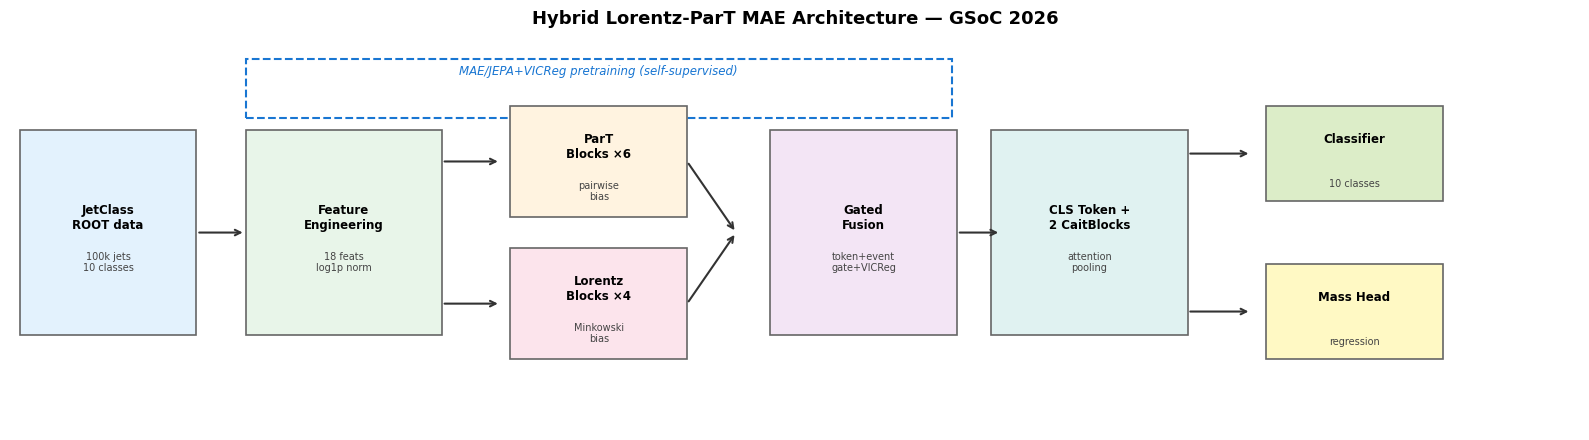

Saved: ./architecture.png


In [12]:
def plot_architecture_diagram():
    fig, ax = plt.subplots(figsize=(16, 4.5))
    ax.set_xlim(0, 16); ax.set_ylim(0, 5); ax.axis('off')

    boxes = [
        (1.0, 2.5, 1.8, 2.6, 'JetClass\nROOT data', '100k jets\n10 classes',    '#E3F2FD'),
        (3.4, 2.5, 2.0, 2.6, 'Feature\nEngineering', '18 feats\nlog1p norm',    '#E8F5E9'),
        (6.0, 3.4, 1.8, 1.4, 'ParT\nBlocks Ã—6',     'pairwise\nbias',          '#FFF3E0'),
        (6.0, 1.6, 1.8, 1.4, 'Lorentz\nBlocks Ã—4',  'Minkowski\nbias',         '#FCE4EC'),
        (8.7, 2.5, 1.9, 2.6, 'Gated\nFusion',       'token+event\ngate+VICReg','#F3E5F5'),
        (11.0,2.5, 2.0, 2.6, 'CLS Token +\n2 CaitBlocks','attention\npooling', '#E0F2F1'),
        (13.7,3.5, 1.8, 1.2, 'Classifier',           '10 classes',              '#DCEDC8'),
        (13.7,1.5, 1.8, 1.2, 'Mass Head',            'regression',              '#FFF9C4'),
    ]
    for xc, yc, w, h, lbl, sub, col in boxes:
        ax.add_patch(plt.Rectangle((xc-w/2, yc-h/2), w, h,
                     facecolor=col, edgecolor='#666', lw=1.2, zorder=2))
        ax.text(xc, yc+0.18, lbl, ha='center', va='center', fontsize=8.5, fontweight='bold', zorder=3)
        ax.text(xc, yc-0.38, sub, ha='center', va='center', fontsize=7,   color='#444',       zorder=3)

    arrows = [(1.9,2.5,0.5,0),(4.4,3.4,0.6,0),(4.4,1.6,0.6,0),
              (6.9,3.4,0.5,-0.9),(6.9,1.6,0.5,0.9),(9.65,2.5,0.45,0),
              (12.0,3.5,0.65,0),(12.0,1.5,0.65,0)]
    for x,y,dx,dy in arrows:
        ax.annotate('', xy=(x+dx,y+dy), xytext=(x,y),
                    arrowprops=dict(arrowstyle='->', color='#333', lw=1.5), zorder=4)

                             
    ax.add_patch(plt.Rectangle((2.4, 3.95), 7.2, 0.75, facecolor='none',
                                edgecolor='#1976D2', lw=1.5, ls='--', zorder=1))
    ax.text(6.0, 4.5, 'MAE/JEPA+VICReg pretraining (self-supervised)',
            ha='center', fontsize=8.5, color='#1976D2', style='italic')

    ax.set_title('Hybrid Lorentz-ParT MAE Architecture â€” GSoC 2026',
                 fontsize=13, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.savefig('./architecture.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: ./architecture.png')

plot_architecture_diagram()


In [13]:
class ParticleFeatureEmbed(nn.Module):
    def __init__(self, in_dim: int, d: int, drop: float):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, d))
    def forward(self, x):
        return self.net(x)

class PairwiseFeatureEncoder(nn.Module):
    def __init__(self, in_dim: int, heads: int):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 32), nn.GELU(), nn.Linear(32, heads))
    def forward(self, pair):
        return self.proj(pair).permute(0,3,1,2).contiguous()


In [14]:
class ParTAttentionBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1,
                 gate_strength: float = 1.0):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)
        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

                                                                                  
        self.gate_strength = gate_strength
        self.interaction_gate_bias = nn.Parameter(torch.zeros(1, heads, 1, 1))

    def forward(self, x, mask, pair_bias):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)

        attn = (q @ k.transpose(-2,-1)) * self.scale
        if pair_bias is not None:
            gate = torch.sigmoid(self.gate_strength * pair_bias + self.interaction_gate_bias)
            attn = attn + gate * pair_bias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B, N, D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [15]:
class LightweightLorentzBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)

        self.inv_proj = nn.Sequential(nn.Linear(3, 32), nn.GELU(), nn.Linear(32, heads))

        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    @staticmethod
    def mdot(a, b):
        return a[...,0]*b[...,0] - (a[...,1]*b[...,1] + a[...,2]*b[...,2] + a[...,3]*b[...,3])

    def lorentz_bias(self, p4, mask, eps: float = 1e-8):
        pi, pj = p4.unsqueeze(2), p4.unsqueeze(1)
        md = self.mdot(pi, pj)
        mi2 = self.mdot(pi, pi)
        mj2 = self.mdot(pj, pj)
        sij = self.mdot(pi+pj, pi+pj)

        feats = torch.stack([
            torch.log(torch.clamp(md.abs(), min=eps)),
            torch.log(torch.clamp(0.5*(mi2.abs()+mj2.abs()), min=eps)),
            torch.log(torch.clamp(sij.abs(), min=eps)),
        ], dim=-1)
        bias = self.inv_proj(feats).permute(0,3,1,2).contiguous()
        valid = (mask.unsqueeze(2)*mask.unsqueeze(1)).unsqueeze(1)
        return bias * valid

    def forward(self, x, p4, mask, precomputed_bias=None):
        B, N, D = x.shape
        lbias = precomputed_bias if precomputed_bias is not None else self.lorentz_bias(p4, mask)
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)
        attn = (q @ k.transpose(-2,-1)) * self.scale + lbias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B,N,D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [16]:
class HybridGatedFusion(nn.Module):
    def __init__(self, d: int, token_gate: bool = True, event_gate: bool = True):
        super().__init__()
        self.token_gate = token_gate
        self.event_gate = event_gate
        if token_gate:
            self.gtok = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        if event_gate:
            self.gevt = nn.Sequential(nn.Linear(2*d, d//2), nn.GELU(), nn.Linear(d//2, 1), nn.Sigmoid())

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def forward(self, xp, xl, mask):
        c = torch.cat([xp, xl], dim=-1)
        gtok = self.gtok(c) if self.token_gate else torch.full_like(xp, 0.5)
        fused = gtok * xp + (1-gtok) * xl

        if self.event_gate:
            ep = self.masked_mean(xp, mask)
            el = self.masked_mean(xl, mask)
            ge = self.gevt(torch.cat([ep, el], dim=-1))
            fused = ge.unsqueeze(-1)*fused + (1-ge.unsqueeze(-1))*0.5*(xp+xl)
        else:
            ge = torch.full((xp.shape[0],1), 0.5, device=xp.device)

        return fused * mask.unsqueeze(-1), gtok, ge


In [17]:
class MaskedDecoderHead(nn.Module):
    def __init__(self, d: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d), nn.GELU(),
            nn.Linear(d, out_dim)
        )
    def forward(self, x):
        return self.net(x)


class ClassAttentionBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1_cls  = nn.LayerNorm(d)
        self.n1_part = nn.LayerNorm(d)
        self.q_proj   = nn.Linear(d, d)
        self.kv_proj  = nn.Linear(d, 2 * d)
        self.out_proj = nn.Linear(d, d)
        self.n2  = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, d),
        )
        self.drop = nn.Dropout(drop)

    def forward(self, x_class: torch.Tensor,
                x_particles: torch.Tensor,
                mask: torch.Tensor) -> torch.Tensor:
        B, N, D = x_particles.shape

                   
        xc_n = self.n1_cls(x_class).unsqueeze(1)                  
        xp_n = self.n1_part(x_particles)                           

                                                              
        Q  = self.q_proj(xc_n).reshape(B, 1, self.h, self.dh).permute(0, 2, 1, 3)
        z  = torch.cat([xc_n, xp_n], dim=1)                          
        KV = self.kv_proj(z).reshape(B, N + 1, 2, self.h, self.dh)
        K  = KV[:, :, 0].permute(0, 2, 1, 3)
        V  = KV[:, :, 1].permute(0, 2, 1, 3)

        attn = (Q @ K.transpose(-2, -1)) * self.scale                    

                                                                      
        cls_valid  = torch.ones(B, 1, device=mask.device)
        full_valid = torch.cat([cls_valid, mask], dim=1)            
        attn = attn.masked_fill(
            ~(full_valid.unsqueeze(1).unsqueeze(2) > 0.5),
            torch.finfo(attn.dtype).min,
        )
        attn = torch.softmax(attn, dim=-1)

        out = (attn @ V).squeeze(2).reshape(B, D)                 

                                               
        x_class = x_class + self.drop(self.out_proj(out))
        x_class = x_class + self.drop(self.mlp(self.n2(x_class)))
        return x_class


class ClassificationHead(nn.Module):
    def __init__(self, d: int, ncls: int, drop: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.net  = nn.Sequential(
            nn.Linear(d, d),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d // 2, ncls),
        )
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(self.norm(z))


class OptionalMassRegressionHead(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d // 2), nn.GELU(),
            nn.Linear(d // 2, 1),
        )
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z).squeeze(-1)


In [18]:
class HybridLorentzParTMAE(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg  = cfg
        fin = len(cfg.PER_PARTICLE_FEATURES)
        d   = cfg.EMBED_DIM

                                                                                                                                                                                       
        self.embed = ParticleFeatureEmbed(fin, d, cfg.DROPOUT)
        self.penc  = PairwiseFeatureEncoder(len(cfg.PAIRWISE_FEATURES), cfg.NUM_HEADS)

                                                                                                       
        self.part = nn.ModuleList([
            ParTAttentionBlock(
                d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT,
                gate_strength=cfg.ATTN_INTERACTION_GATE_STRENGTH,
            )
            for _ in range(max(cfg.NUM_LAYERS_PART, 1))
        ])
        self.lor  = nn.ModuleList([
            LightweightLorentzBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT)
            for _ in range(max(cfg.NUM_LAYERS_LORENTZ, 1))
        ])

                                                                                                                                                                   
        self.fusion = HybridGatedFusion(d, cfg.USE_TOKEN_GATE, cfg.USE_EVENT_GATE)

                                                                                     
                                                                            
        self.cls_token = nn.Parameter(torch.zeros(1, d))
        nn.init.trunc_normal_(self.cls_token, std=0.02)                     

        num_cls = getattr(cfg, 'NUM_CLS_BLOCKS', 2)
        self.cls_blocks = nn.ModuleList([
            ClassAttentionBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT)
            for _ in range(num_cls)
        ])

                                                                                                                                                                                 
                                                                       
                                                                              
        reco_dim = fin - 1                                                
        self.dec  = MaskedDecoderHead(d, reco_dim)
        self.cls  = ClassificationHead(d, cfg.NUM_CLASSES, cfg.DROPOUT)
        self.mass = OptionalMassRegressionHead(d)

                                                                        
    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def _pool(self, hf: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        B = hf.size(0)
        cls = self.cls_token.expand(B, -1)              
        for blk in self.cls_blocks:
            cls = blk(cls, hf, mask)
        return cls                                       

    def encode(self, x, p4, mask):
        h0    = self.embed(x) * mask.unsqueeze(-1)
        pair  = compute_pairwise_features_from_p4(p4, mask)
        pbias = self.penc(pair)

        hp = h0
        for blk in self.part[:self.cfg.NUM_LAYERS_PART]:
            hp = blk(hp, mask, pbias)

                                                                                   
                                                                  
                                                                           
        lor_bias = self.lor[0].lorentz_bias(p4, mask) if self.cfg.NUM_LAYERS_LORENTZ > 0 else None
        hl = h0
        for blk in self.lor[:self.cfg.NUM_LAYERS_LORENTZ]:
            hl = blk(hl, p4, mask, precomputed_bias=lor_bias)

        return hp, hl

    def forward(self, x, p4, mask, mode: str = 'finetune'):
        hp, hl = self.encode(x, p4, mask)
        hf, gtok, gevt = self.fusion(hp, hl, mask)

                                                                 
        pooled = self._pool(hf, mask)

        out = {
            'logits':    self.cls(pooled),
            'mass_pred': self.mass(pooled),
                                                            
                                                               
            'reco':      self.dec(hf),
            'g_tok':     gtok,
            'g_evt':     gevt,
        }
        if mode == 'pretrain':
            return {'reco': out['reco'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'finetune':
            return {'logits': out['logits'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'multitask':
            return out
        raise ValueError(f'Unknown mode: {mode}')

## 8. Loss Functions
We combine reconstruction and classification objectives with weights tuned for stable optimization.

In [19]:
                                                                            
PHI_FEAT_NAME = 'phi'                                         


def _phi_idx(feat_names):
    try:
        return list(feat_names).index(PHI_FEAT_NAME)
    except ValueError:
        return None


def build_reco_feature_weights(cfg, feat_idx: Dict[str, int], reco_dim: int,
                               device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    w = torch.full((reco_dim,), float(cfg.RECO_WEIGHT_DEFAULT), device=device, dtype=dtype)
    named = {
        'pt': cfg.RECO_WEIGHT_PT,
        'eta': cfg.RECO_WEIGHT_ETA,
        'phi': cfg.RECO_WEIGHT_PHI,
        'E': cfg.RECO_WEIGHT_E,
    }
    for name, val in named.items():
        idx = feat_idx.get(name, None)
        if idx is not None and idx < reco_dim:
            w[idx] = float(val)
    return w


def masked_reco_loss(reco: torch.Tensor, target: torch.Tensor,
                     masked_token_indicator: torch.Tensor,
                     phi_feat_idx: Optional[int] = None,
                     feature_weights: Optional[torch.Tensor] = None) -> torch.Tensor:
                                                                                
    reco_dim = reco.shape[-1]
    target   = target[..., :reco_dim]                     

    w = masked_token_indicator.unsqueeze(-1).float()
    n_feat = reco.shape[-1]

    if feature_weights is None:
        feature_weights = torch.ones((n_feat,), device=reco.device, dtype=reco.dtype)
    feature_weights = feature_weights.view(1, 1, n_feat)

                                                                
    smooth_l1 = F.smooth_l1_loss(reco * w, target * w, reduction='none')
    loss_total = (smooth_l1 * w * feature_weights).sum() / w.sum().clamp_min(1.0)

                                                   
    if phi_feat_idx is not None and phi_feat_idx < n_feat:
        phi_pred = reco[..., phi_feat_idx]
        phi_true = target[..., phi_feat_idx]
        phi_mask = masked_token_indicator.float()
        cos_loss = (1.0 - (torch.cos(phi_true) * torch.cos(phi_pred)
                           + torch.sin(phi_true) * torch.sin(phi_pred)))
        phi_weight = feature_weights[..., phi_feat_idx]
        phi_term = ((cos_loss * phi_mask) * phi_weight).sum() / phi_mask.sum().clamp_min(1.0)

        phi_mse = ((smooth_l1[..., phi_feat_idx] * phi_mask) * phi_weight).sum() / phi_mask.sum().clamp_min(1.0)
        loss_total = loss_total - phi_mse + phi_term

    return loss_total


def conservation_loss(reco: torch.Tensor, target: torch.Tensor,
                      masked_token_indicator: torch.Tensor,
                      feat_idx: Dict[str, int]) -> torch.Tensor:
    iE  = feat_idx['E']
    ipx = feat_idx['px']
    ipy = feat_idx['py']
    ipz = feat_idx['pz']
    m = masked_token_indicator.float()

    def _sum4(arr):
        return torch.stack([
            (arr[..., iE]  * m).sum(1),
            (arr[..., ipx] * m).sum(1),
            (arr[..., ipy] * m).sum(1),
            (arr[..., ipz] * m).sum(1),
        ], dim=-1)

    pred4 = _sum4(reco)
    true4 = _sum4(target)

    lp4 = F.smooth_l1_loss(pred4, true4)
    pm2 = pred4[:, 0]**2 - (pred4[:, 1]**2 + pred4[:, 2]**2 + pred4[:, 3]**2)
    tm2 = true4[:, 0]**2 - (true4[:, 1]**2 + true4[:, 2]**2 + true4[:, 3]**2)
    lm  = F.smooth_l1_loss(torch.clamp(pm2, min=0.0), torch.clamp(tm2, min=0.0))
    return lp4 + 0.5 * lm


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction='none',
                             label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def gate_regularization(out: Dict[str, torch.Tensor], weight: float) -> torch.Tensor:
    if weight <= 0.0 or 'g_evt' not in out:
        return torch.tensor(0.0, device=out['reco'].device if 'reco' in out else out['logits'].device)
    device = out['g_evt'].device
    ge = out['g_evt']          
                                       
    mean_reg = torch.abs(ge.mean() - 0.5)
                                                                             
    eps = 1e-6
    entropy = -(ge * torch.log(ge + eps) + (1 - ge) * torch.log(1 - ge + eps)).mean()
                                                                                     
    entropy_reg = 0.693 - entropy                                       
    return weight * (mean_reg + 0.5 * entropy_reg)


def pretrain_total_loss(out, target_x, masked_token_indicator, cfg, feat_idx):
    phi_idx = feat_idx.get('phi', None)
    reco_weights = None
    if getattr(cfg, 'USE_PHYSICS_RECO_WEIGHTING', False):
        reco_weights = build_reco_feature_weights(
            cfg, feat_idx, out['reco'].shape[-1],
            device=out['reco'].device, dtype=out['reco'].dtype,
        )

    lr = masked_reco_loss(
        out['reco'], target_x, masked_token_indicator,
        phi_feat_idx=phi_idx, feature_weights=reco_weights,
    )
    lc = conservation_loss(out['reco'], target_x, masked_token_indicator, feat_idx)
    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = cfg.W_RECO * lr + cfg.W_CONS * lc + lgate

                                                              
    vicreg_val = torch.tensor(0.0, device=total.device)
    if getattr(cfg, 'USE_JEPA_PRETRAIN', False) and 'jepa_pred' in out:
        pred_flat = out['jepa_pred'].reshape(-1, out['jepa_pred'].shape[-1])
        if pred_flat.shape[0] > 1:
            vicreg_val = vicreg_loss(pred_flat.float())
            total = total + 0.05 * vicreg_val                                      

    return total, {'reco': lr.item(), 'cons': lc.item(),
                   'jepa': vicreg_val.item(),
                   'gate_reg': float(lgate.item())}


def finetune_total_loss(out, batch, cfg, focal=False,
                        class_weights: Optional[torch.Tensor] = None):
    if focal:
        lcls = FocalLoss(label_smoothing=cfg.LABEL_SMOOTHING)(
            out['logits'], batch['y'])
    else:
        lcls = F.cross_entropy(
            out['logits'], batch['y'],
            weight=class_weights,
            label_smoothing=cfg.LABEL_SMOOTHING,
        )
    total = cfg.W_CLASS * lcls
    logs  = {'cls': lcls.item()}

    if cfg.USE_AUX_MASS and 'mass_pred' in out:
        lm = F.smooth_l1_loss(out['mass_pred'], batch['mass'])
        total = total + cfg.AUX_MASS_WEIGHT * lm
        logs['mass'] = lm.item()

    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = total + lgate
    logs['gate_reg'] = float(lgate.item())

    return total, logs

## 9. Training Utilities
Helper functions for scheduling, logging, checkpointing, and early stopping are defined here.

In [20]:
class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

                                               
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


In [21]:
class JEPAPretrainer(nn.Module):
    def __init__(self, online_model: HybridLorentzParTMAE, ema_decay: float = 0.996):
        super().__init__()
        self.online_model = online_model
        self.target_model = copy.deepcopy(online_model).eval()
        for p in self.target_model.parameters():
            p.requires_grad_(False)

        d = online_model.cfg.EMBED_DIM
        self.predictor = nn.Sequential(
            nn.Linear(d, d // 2),
            nn.LayerNorm(d // 2),
            nn.GELU(),
            nn.Linear(d // 2, d),
        )
        self.ema_decay = ema_decay

    @torch.no_grad()
    def update_target(self):
        for p_o, p_t in zip(self.online_model.parameters(), self.target_model.parameters()):
            p_t.data.mul_(self.ema_decay).add_(p_o.data, alpha=1.0 - self.ema_decay)

    def forward(self, x_masked, x_full, p4, mask, masked_token_indicator):
        hp_o, hl_o = self.online_model.encode(x_masked, p4, mask)
        hf_o, _, _ = self.online_model.fusion(hp_o, hl_o, mask)
        pred = self.predictor(hf_o)

        with torch.no_grad():
            hp_t, hl_t = self.target_model.encode(x_full, p4, mask)
            hf_t, _, _ = self.target_model.fusion(hp_t, hl_t, mask)
            tgt = F.layer_norm(hf_t, hf_t.shape[-1:])

        m = masked_token_indicator.bool()
        if m.any():
            return F.smooth_l1_loss(pred[m], tgt[m])
        return torch.tensor(0.0, device=pred.device, dtype=pred.dtype)


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

                                               
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def train_epoch_pretrain(model, loader, opt, amp_scaler, device, cfg, feat_idx,
                         jepa_helper: Optional[JEPAPretrainer] = None):
    model.train()
    lm, lr, lc, lv, lj = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Pretrain', leave=False):
        batch = to_device(batch, device)
        vis_x, target_x, reco_mask, _ = build_mae_targets(
            batch['x'], batch['p4'], batch['mask'],
            cfg.MASK_RATIO,
            biased=cfg.USE_BIASED_MASK)
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(vis_x, batch['p4'], batch['mask'], mode='pretrain')
            loss_mae, logs = pretrain_total_loss(out, target_x, reco_mask, cfg, feat_idx)
            loss = loss_mae

            jepa_val = torch.tensor(0.0, device=loss_mae.device)
            use_jepa = bool(getattr(cfg, 'USE_JEPA_PRETRAIN', False)) and (jepa_helper is not None)
            if use_jepa:
                jepa_val = jepa_helper(vis_x, batch['x'], batch['p4'], batch['mask'], reco_mask)
                loss = loss + float(getattr(cfg, 'JEPA_WEIGHT', 0.0)) * jepa_val
                logs['jepa'] = float(jepa_val.item())
            else:
                logs['jepa'] = 0.0

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        if bool(getattr(cfg, 'USE_JEPA_PRETRAIN', False)) and (jepa_helper is not None):
            jepa_helper.update_target()

        bsz = batch['x'].size(0)
        lm.update(loss.item(), bsz)
        lr.update(logs['reco'], bsz)
        lc.update(logs['cons'], bsz)
        lv.update(logs.get('vicreg', 0.0), bsz)
        lj.update(logs['jepa'], bsz)

    return {'loss': lm.avg, 'reco': lr.avg, 'cons': lc.avg, 'vicreg': lv.avg, 'jepa': lj.avg,
            'time': time.time() - t0}


def train_epoch_finetune(model, loader, opt, amp_scaler, device, cfg,
                         class_weights: Optional[torch.Tensor] = None):
    model.train()
    lm, am = AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Finetune', leave=False):
        batch = to_device(batch, device)
        opt.zero_grad(set_to_none=True)

        mode = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
            loss, _ = finetune_total_loss(out, batch, cfg,
                                          class_weights=class_weights)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        pred = out['logits'].argmax(1)
        acc  = (pred == batch['y']).float().mean().item()
        bsz  = batch['x'].size(0)
        lm.update(loss.item(), bsz); am.update(acc, bsz)

    return {'loss': lm.avg, 'acc': am.avg, 'time': time.time() - t0}


@torch.no_grad()
def eval_finetune(model, loader, device, cfg):
    model.eval()
    Y, P, YH, MT, MP = [], [], [], [], []
    for batch in tqdm(loader, desc='Eval', leave=False):
        batch = to_device(batch, device)
        mode  = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        out   = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
        prob  = torch.softmax(out['logits'], dim=1)
        yhat  = prob.argmax(1)
        Y.append(batch['y'].cpu().numpy())
        P.append(prob.cpu().numpy())
        YH.append(yhat.cpu().numpy())
        MT.append(batch['mass'].cpu().numpy())
        if 'mass_pred' in out:
            MP.append(out['mass_pred'].cpu().numpy())

    y = np.concatenate(Y); p = np.concatenate(P); yh = np.concatenate(YH)
    met = {'accuracy': accuracy_score(y, yh)}
    try:
        met['macro_auc_ovr'] = roc_auc_score(
            y, p, multi_class='ovr', average='macro')
        met['macro_auc_ovo'] = roc_auc_score(
            y, p, multi_class='ovo', average='macro')
    except Exception:
        met['macro_auc_ovr'] = np.nan
        met['macro_auc_ovo'] = np.nan

    if len(MP):
        mt, mp = np.concatenate(MT), np.concatenate(MP)
        if getattr(cfg, 'MASS_TARGET_NORMALIZE', False):
            mass_mean = float(getattr(cfg, 'MASS_MEAN', 0.0))
            mass_std = float(getattr(cfg, 'MASS_STD', 1.0))
            mt = mt * mass_std + mass_mean
            mp = mp * mass_std + mass_mean
        met['mass_mae']  = mean_absolute_error(mt, mp)
        met['mass_rmse'] = float(np.sqrt(mean_squared_error(mt, mp)))

    return met, y, p, yh

## 10. Evaluation Metrics
Model quality is tracked with accuracy, macro-AUC, and class-wise diagnostics.

In [22]:
def plot_curves(hist: Dict[str, List[float]], title: str):
    plt.figure(figsize=(8, 4))
    for k, v in hist.items():
        plt.plot(v, label=k)
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Value')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


def plot_confusion(y, yh, class_names):
    cm  = confusion_matrix(y, yh)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title in zip(axes, [cm, cmn],
                                ['Confusion Matrix (counts)',
                                 'Confusion Matrix (row-normalised)']):
        im = ax.imshow(data, cmap='Blues',
                       vmin=0, vmax=(None if 'counts' in title else 1))
        ax.set_title(title)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


def plot_rocs(y, p, class_names):
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(C):
        try:
            fpr, tpr, _ = roc_curve(yoh[:, i], p[:, i])
            ax.plot(fpr, tpr,
                    label=f'{class_names[i]}  AUC={auc(fpr, tpr):.3f}')
        except Exception:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title('Per-class ROC curves (one-vs-rest)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def bkg_rej_at_sig_eff(y: np.ndarray, p: np.ndarray,
                        sig_class: int = 0, eff: float = 0.5) -> float:
    yb = (y == sig_class).astype(int)
    fpr, tpr, _ = roc_curve(yb, p[:, sig_class])
    i = np.argmin(np.abs(tpr - eff))
    return float(1.0 / max(fpr[i], 1e-8))


def compute_per_class_metrics(y: np.ndarray, p: np.ndarray,
                               class_names: List[str],
                               cfg) -> pd.DataFrame:
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    rows = []

                                                       
    high_eff_classes = set()                                                        

    for i, name in enumerate(class_names):
        row = {'class': name}
        try:
            fpr_i, tpr_i, _ = roc_curve(yoh[:, i], p[:, i])
            row['AUC'] = float(auc(fpr_i, tpr_i))
        except Exception:
            row['AUC'] = float('nan')

        for sig_eff, label in [(0.50, 'Rej50%'), (0.30, 'Rej30%'),
                                (0.99, 'Rej99%'), (0.995, 'Rej99.5%')]:
            try:
                row[label] = bkg_rej_at_sig_eff(y, p, sig_class=i, eff=sig_eff)
            except Exception:
                row[label] = float('nan')

        rows.append(row)

    df = pd.DataFrame(rows).set_index('class')
    return df


def print_physics_summary(test_metrics: dict, y: np.ndarray,
                           p: np.ndarray, class_names: List[str], cfg):
    print("=" * 60)
    print(f"  Overall accuracy : {test_metrics['accuracy']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovr', np.nan)):
        print(f"  Macro AUC (OvR) : {test_metrics['macro_auc_ovr']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovo', np.nan)):
        print(f"  Macro AUC (OvO) : {test_metrics['macro_auc_ovo']:.4f}")
    if 'mass_mae' in test_metrics:
        print(f"  Mass MAE        : {test_metrics['mass_mae']:.4f}")
        print(f"  Mass RMSE       : {test_metrics['mass_rmse']:.4f}")
    print("=" * 60)

    df = compute_per_class_metrics(y, p, class_names, cfg)
    print("\nPer-class metrics (ParT-paper Table 1 format):")
    print(df.to_string(float_format=lambda x: f"{x:8.1f}" if x > 1 else f"{x:.4f}"))
    return df


## 11. Pretraining Run
Run MAE pretraining and save the encoder checkpoint for downstream fine-tuning.

In [23]:
train_loader, val_loader, test_loader, meta = build_loaders(cfg)
class_names   = meta['classes']
class_weights = torch.tensor(meta['class_weights'], dtype=torch.float32, device=device)
if not cfg.USE_CLASS_WEIGHTS:
    class_weights = None

print('Classes:', class_names)
print('Batches train/val/test:',
      len(train_loader), len(val_loader), len(test_loader))
if class_weights is not None:
    print('Class weights:', class_weights.detach().cpu().numpy())

model    = HybridLorentzParTMAE(cfg).to(device)
model    = maybe_compile(model)                                
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

opt      = make_optimizer(model, cfg)                                 
sch      = make_scheduler(opt, cfg.PRETRAIN_EPOCHS,
                          warmup_epochs=cfg.WARMUP_EPOCHS)                   
amp_scaler = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
feat_idx = {k: i for i, k in enumerate(cfg.PER_PARTICLE_FEATURES)}

jepa_helper = None
if cfg.USE_JEPA_PRETRAIN:
    jepa_helper = JEPAPretrainer(model, ema_decay=cfg.JEPA_EMA_DECAY).to(device)
    print(f"[INFO] JEPA enabled: weight={cfg.JEPA_WEIGHT:.3f}, ema_decay={cfg.JEPA_EMA_DECAY:.4f}")

pre_hist = {'loss': [], 'reco': [], 'cons': [], 'jepa': [], 'lr': []}
for ep in range(cfg.PRETRAIN_EPOCHS):
    logs = train_epoch_pretrain(model, train_loader, opt, amp_scaler,
                                device, cfg, feat_idx,
                                jepa_helper=jepa_helper)
    current_lr = sch.get_last_lr()[0]
    sch.step()
    pre_hist['loss'].append(logs['loss'])
    pre_hist['reco'].append(logs['reco'])
    pre_hist['cons'].append(logs['cons'])
    pre_hist['jepa'].append(logs.get('jepa', 0.0))
    pre_hist['lr'].append(current_lr)
    print(f"[Pretrain {ep+1:2d}/{cfg.PRETRAIN_EPOCHS}]"
          f"  loss={logs['loss']:.4f}"
          f"  reco={logs['reco']:.4f}"
          f"  cons={logs['cons']:.4f}"
          f"  jepa={logs.get('jepa', 0.0):.4f}"
          f"  lr={current_lr:.2e}"
          f"  t={logs['time']:.1f}s")

Reading ROOT:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] progress files=10/100 seen_events=25000 kept_samples=25000
[INFO] progress files=20/100 seen_events=50000 kept_samples=50000
[INFO] progress files=30/100 seen_events=75000 kept_samples=75000
[INFO] progress files=40/100 seen_events=100000 kept_samples=100000
[INFO] progress files=50/100 seen_events=125000 kept_samples=100000
[INFO] progress files=60/100 seen_events=150000 kept_samples=100000
[INFO] progress files=70/100 seen_events=175000 kept_samples=100000
[INFO] progress files=80/100 seen_events=200000 kept_samples=100000
[INFO] progress files=90/100 seen_events=225000 kept_samples=100000
[INFO] progress files=100/100 seen_events=250000 kept_samples=100000
[INFO] Total loaded events: 250000
[INFO] Sampled events: 100000 (target=100000)
[INFO] Split counts train/val/test = 80000/10000/10000
[INFO] Split ratios train/val/test = 0.800/0.100/0.100
[INFO] Mass target normalization: mean=113.9527, std=37.4831
Classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TT

Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain  1/20]  loss=3.4579  reco=2.4479  cons=5.0470  jepa=0.0000  lr=1.00e-04  t=156.3s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

...

[Pretrain 18/20]  loss=0.5607  reco=0.5041  cons=0.2828  jepa=0.0000  lr=2.52e-05  t=146.3s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain 19/20]  loss=0.5595  reco=0.5047  cons=0.2739  jepa=0.0000  lr=1.30e-05  t=145.0s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain 20/20]  loss=0.5541  reco=0.5025  cons=0.2575  jepa=0.0000  lr=5.53e-06  t=161.5s


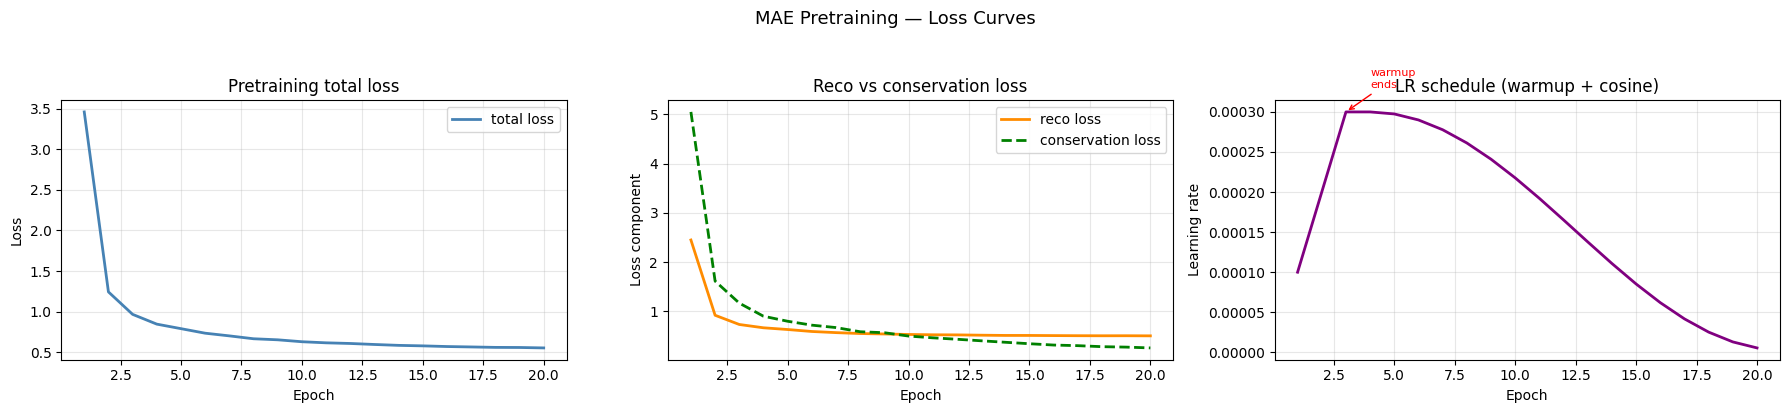

Saved: ./pretraining_curves.png
Best pretrain loss: 0.5541 at epoch 20


In [25]:
                                                                                                                                                                         
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs = range(1, len(pre_hist["loss"]) + 1)

axes[0].plot(epochs, pre_hist["loss"],  color='steelblue', lw=2, label='total loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Pretraining total loss'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, pre_hist["reco"],  color='darkorange', lw=2, label='reco loss')
axes[1].plot(epochs, pre_hist["cons"],  color='green',      lw=2, label='conservation loss', ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss component')
axes[1].set_title('Reco vs conservation loss'); axes[1].grid(alpha=0.3); axes[1].legend()

axes[2].plot(epochs, pre_hist["lr"], color='purple', lw=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning rate')
axes[2].set_title('LR schedule (warmup + cosine)'); axes[2].grid(alpha=0.3)
axes[2].annotate('warmup\nends', xy=(cfg.WARMUP_EPOCHS, pre_hist["lr"][cfg.WARMUP_EPOCHS-1]),
                 fontsize=8, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'),
                 xytext=(cfg.WARMUP_EPOCHS+1, pre_hist["lr"][cfg.WARMUP_EPOCHS-1]*1.1))

plt.suptitle('MAE Pretraining â€” Loss Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./pretraining_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: ./pretraining_curves.png')
print(f'Best pretrain loss: {min(pre_hist["loss"]):.4f} at epoch {pre_hist["loss"].index(min(pre_hist["loss"]))+1}')

In [26]:
@torch.no_grad()
def show_reco_examples(model, loader, cfg, n_events=2):
    model.eval()
    batch = next(iter(loader)); batch = to_device(batch, device)
    vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
    out = model(vis, batch['p4'], batch['mask'], mode='pretrain')

    names = list(cfg.PER_PARTICLE_FEATURES)
    for b in range(min(n_events, batch['x'].size(0))):
        idx = torch.where(rm[b])[0][:8]
        if len(idx) == 0: continue
        print(f'Event {b}, masked tokens shown: {len(idx)}')
        for fname in ['px','py','pz','E','pt']:
            j = names.index(fname)
            t = tgt[b, idx, j].detach().cpu().numpy()
            p = out['reco'][b, idx, j].detach().cpu().numpy()
            print(f'  {fname} true[:4]={np.round(t[:4],3)} pred[:4]={np.round(p[:4],3)}')

show_reco_examples(model, train_loader, cfg)


Event 0, masked tokens shown: 8
  px true[:4]=[-4.762 -1.954 -1.957 -1.811] pred[:4]=[-4.585 -1.981 -1.947 -1.833]
  py true[:4]=[4.997 2.782 2.739 2.619] pred[:4]=[5.119 2.8   2.741 2.627]
  pz true[:4]=[5.133 2.63  2.58  2.378] pred[:4]=[5.076 2.609 2.569 2.437]
  E true[:4]=[5.533 3.082 3.039 2.882] pred[:4]=[5.518 3.077 3.018 2.897]
  pt true[:4]=[5.238 2.852 2.815 2.689] pred[:4]=[5.19  2.866 2.819 2.694]
Event 1, masked tokens shown: 8
  px true[:4]=[-2.926 -2.733 -2.514 -2.447] pred[:4]=[-2.953 -2.802 -2.525 -2.456]
  py true[:4]=[3.92  3.423 3.451 3.404] pred[:4]=[3.969 3.511 3.507 3.485]
  pz true[:4]=[-3.602 -3.049 -3.126 -3.047] pred[:4]=[-3.635 -3.185 -3.17  -3.127]
  E true[:4]=[4.165 3.679 3.694 3.634] pred[:4]=[4.192 3.795 3.747 3.708]
  pt true[:4]=[3.979 3.525 3.514 3.464] pred[:4]=[4.009 3.611 3.556 3.517]


## 12. Fine-Tuning Run
Load pretrained weights (or train from scratch) and optimize the classifier on labeled data.
Best model selection uses validation metrics for robust checkpointing.

In [27]:
ckpt_path = Path('./checkpoints/hybrid_mae_pretrained.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt_path)

ft_model = HybridLorentzParTMAE(cfg).to(device)
ft_model.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)

                                                                      
optf   = make_optimizer(ft_model, cfg, finetune_mode=True)                    
schf   = make_scheduler(optf, cfg.FINETUNE_EPOCHS,
                        warmup_epochs=cfg.WARMUP_EPOCHS)                      
scalerf = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
early   = EarlyStopping(patience=cfg.EARLY_STOP_PATIENCE, mode='max')

best_path    = Path('./checkpoints/hybrid_mae_best_finetune.pt')
best_val_auc = -np.inf

ft_hist = {'train_loss': [], 'train_acc': [], 'val_acc': [],
           'val_auc_ovr': [], 'val_auc_ovo': [], 'lr': []}

for ep in range(cfg.FINETUNE_EPOCHS):
    tr = train_epoch_finetune(ft_model, train_loader, optf, scalerf,
                              device, cfg, class_weights=class_weights)
    va, *_ = eval_finetune(ft_model, val_loader, device, cfg)
    current_lr = schf.get_last_lr()[0]
    schf.step()

    val_auc = va['macro_auc_ovr']
    if np.isnan(val_auc):
        val_auc = va['accuracy']

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(ft_model.state_dict(), best_path)

    ft_hist['train_loss'].append(tr['loss'])
    ft_hist['train_acc'].append(tr['acc'])
    ft_hist['val_acc'].append(va['accuracy'])
    ft_hist['val_auc_ovr'].append(va['macro_auc_ovr'])
    ft_hist['val_auc_ovo'].append(va.get('macro_auc_ovo', np.nan))
    ft_hist['lr'].append(current_lr)

    print(f"[Finetune {ep+1:2d}/{cfg.FINETUNE_EPOCHS}]"
          f"  train_loss={tr['loss']:.4f}"
          f"  train_acc={tr['acc']:.4f}"
          f"  val_acc={va['accuracy']:.4f}"
          f"  val_auc={val_auc:.4f}"
          f"  lr={current_lr:.2e}")

    if early.step(val_auc):
        print(f"Early stopping at epoch {ep+1}."
              f" Best val_auc={best_val_auc:.4f}")
        break

if best_path.exists():
    ft_model.load_state_dict(
        torch.load(best_path, map_location=device), strict=False)
    print(f"Loaded best fine-tuned checkpoint (val_auc={best_val_auc:.4f})")


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune  1/35]  train_loss=2.1184  train_acc=0.2148  val_acc=0.3804  val_auc=0.8179  lr=3.00e-05


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune 34/35]  train_loss=1.1204  train_acc=0.7259  val_acc=0.6983  val_auc=0.9519  lr=1.76e-06


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune 35/35]  train_loss=1.1179  train_acc=0.7260  val_acc=0.6970  val_auc=0.9519  lr=1.11e-06
Loaded best fine-tuned checkpoint (val_auc=0.9525)


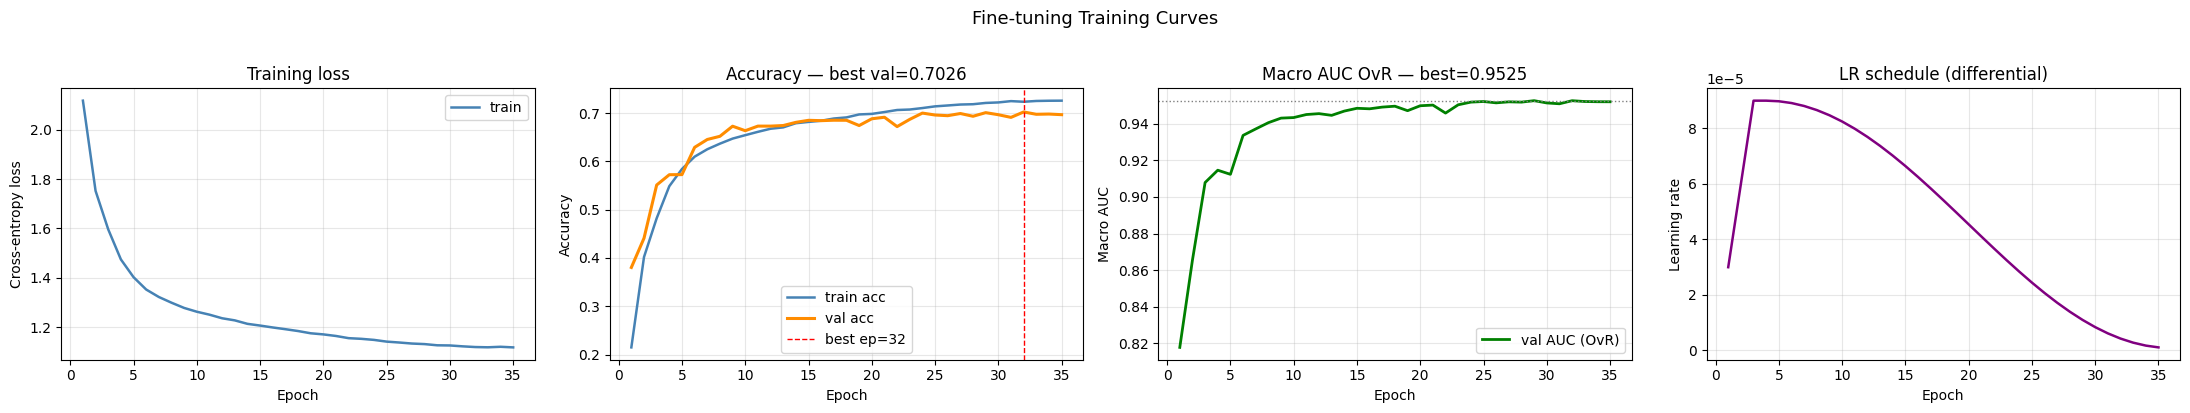

Saved: ./finetuning_curves.png


In [28]:
                                                                                                                                                                         
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
epochs = range(1, len(ft_hist["train_loss"]) + 1)
best_ep = int(np.argmax(ft_hist["val_acc"])) + 1

axes[0].plot(epochs, ft_hist["train_loss"], color='steelblue', lw=1.8, label='train')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training loss'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, ft_hist["train_acc"], color='steelblue', lw=1.8, label='train acc')
axes[1].plot(epochs, ft_hist["val_acc"],   color='darkorange', lw=2.2, label='val acc')
axes[1].axvline(best_ep, color='red', ls='--', lw=1, label=f'best ep={best_ep}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'Accuracy â€” best val={max(ft_hist["val_acc"]):.4f}')
axes[1].grid(alpha=0.3); axes[1].legend()

axes[2].plot(epochs, ft_hist["val_auc_ovr"], color='green', lw=2, label='val AUC (OvR)')
axes[2].axhline(max(ft_hist["val_auc_ovr"]), color='gray', ls=':', lw=1)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro AUC')
axes[2].set_title(f'Macro AUC OvR â€” best={max(ft_hist["val_auc_ovr"]):.4f}')
axes[2].grid(alpha=0.3); axes[2].legend()

axes[3].plot(epochs, ft_hist["lr"], color='purple', lw=1.8)
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Learning rate')
axes[3].set_title('LR schedule (differential)'); axes[3].grid(alpha=0.3)

plt.suptitle('Fine-tuning Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./finetuning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: ./finetuning_curves.png')


Eval:   0%|          | 0/79 [00:00<?, ?it/s]

  Overall accuracy : 0.7020
  Macro AUC (OvR) : 0.9536
  Macro AUC (OvO) : 0.9536

Per-class metrics (ParT-paper Table 1 format):
               AUC   Rej50%      Rej30%   Rej99%  Rej99.5%
class                                                     
HToBB       0.9202     35.7       125.0      1.8       1.6
HToCC       0.9126     35.1       118.3      1.7       1.5
HToGG       0.9394     39.7       112.5      2.4       2.1
HToWW2Q1L   0.9942   1287.9      4507.5     12.6       5.4
HToWW4Q     0.9665     94.7       310.1      3.5       2.8
TTBar       0.9868    243.1       599.7      8.3       5.3
TTBarLep    0.9961   4500.5 100000000.0     10.7       6.2
WToQQ       0.9521     51.1       109.7      2.4       2.2
ZJetsToNuNu 0.9503    219.4      2248.5      1.9       1.7
ZToQQ       0.9174     25.2        57.4      1.7       1.5

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

       HToBB       0.60      0.54      0.57      10

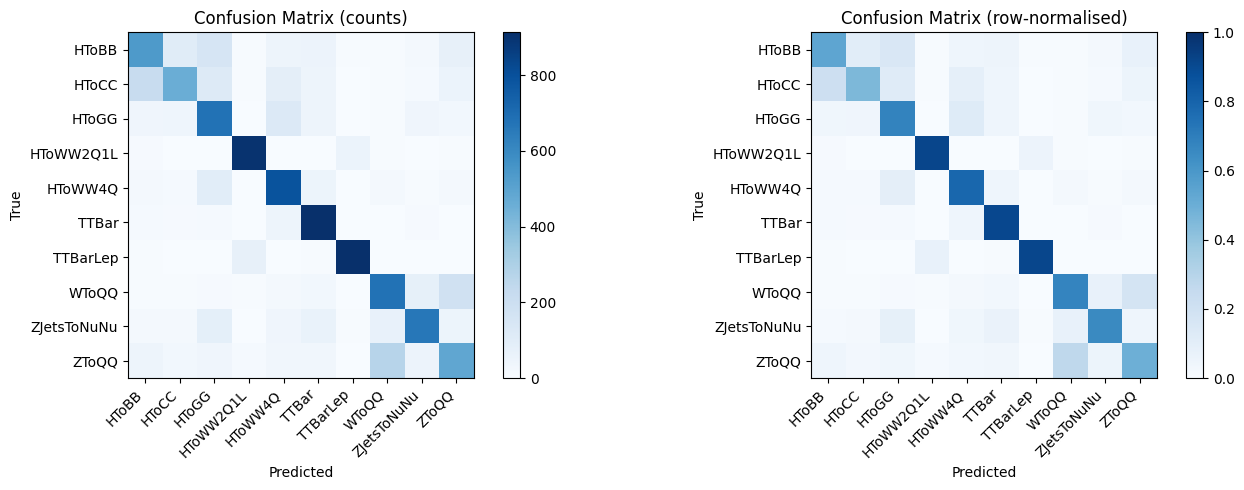

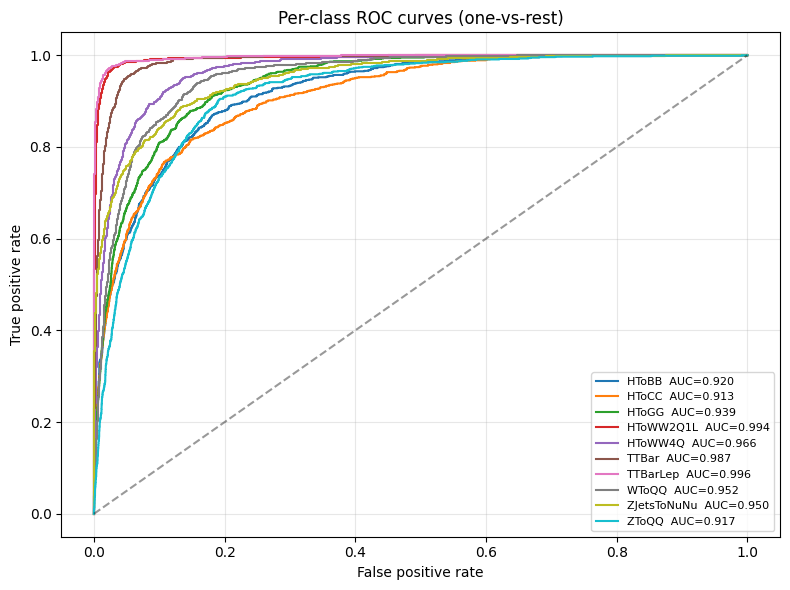


Background rejection at multiple signal efficiencies:
               AUC  Rej50%      Rej30%  Rej99%
class                                         
HToBB       0.9202    35.7       125.0     1.8
HToCC       0.9126    35.1       118.3     1.7
HToGG       0.9394    39.7       112.5     2.4
HToWW2Q1L   0.9942  1287.9      4507.5    12.6
HToWW4Q     0.9665    94.7       310.1     3.5
TTBar       0.9868   243.1       599.7     8.3
TTBarLep    0.9961  4500.5 100000000.0    10.7
WToQQ       0.9521    51.1       109.7     2.4
ZJetsToNuNu 0.9503   219.4      2248.5     1.9
ZToQQ       0.9174    25.2        57.4     1.7


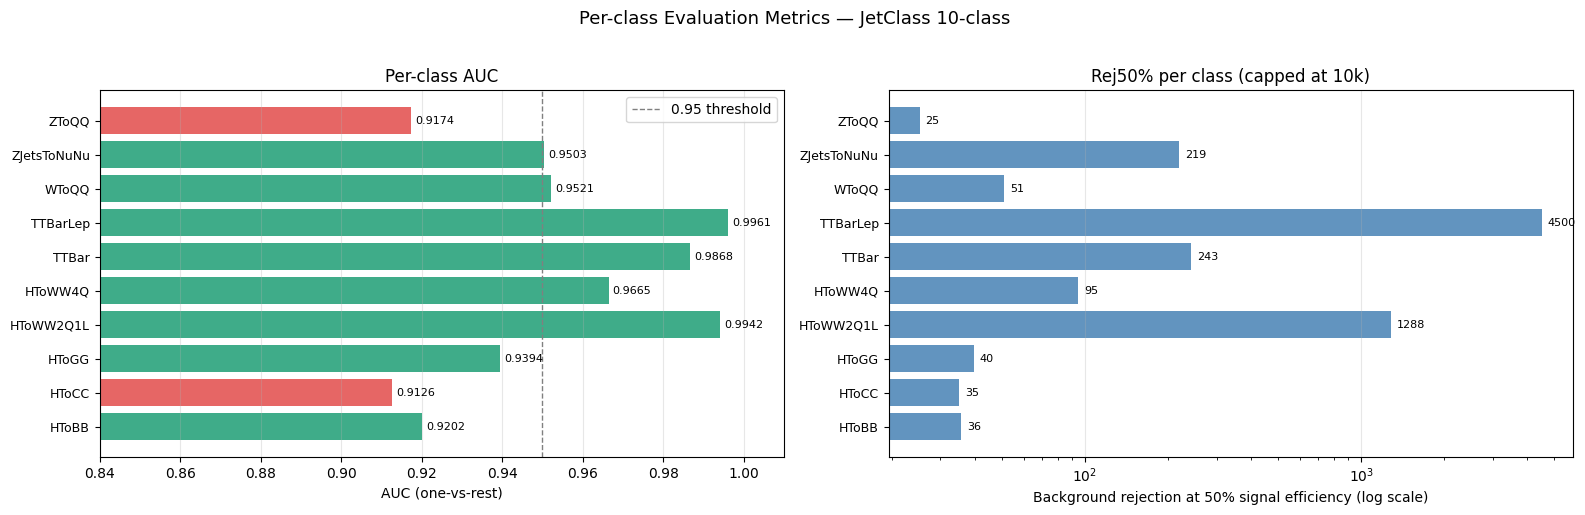

Saved: ./per_class_metrics.png


In [ ]:
test_metrics, y_true, y_prob, y_pred = eval_finetune(
    ft_model, test_loader, device, cfg)

                                                                
per_class_df = print_physics_summary(
    test_metrics, y_true, y_prob, class_names, cfg)

print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(y_true, y_pred,
                             target_names=[str(c) for c in class_names],
                             zero_division=0))

plot_confusion(y_true, y_pred, class_names)
plot_rocs(y_true, y_prob, class_names)

                                      
if per_class_df is not None:
    for col in per_class_df.columns:
        per_class_df[col] = per_class_df[col].clip(upper=10000)

print("\nBackground rejection at multiple signal efficiencies (clipped at 10,000 for display):")
print(per_class_df[["AUC","Rej50%","Rej30%","Rej99%"]].to_string(
    float_format=lambda x: f"{x:.1f}" if x > 1 else f"{x:.4f}"))

                                                                                
if per_class_df is not None and 'AUC' in per_class_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

              
    aucs = per_class_df['AUC'].values
    colors_bar = ['#E24B4A' if a < 0.92 else '#1D9E75' for a in aucs]
    axes[0].barh(range(len(class_names)), aucs, color=colors_bar, alpha=0.85)
    axes[0].set_yticks(range(len(class_names)))
    axes[0].set_yticklabels(class_names, fontsize=9)
    axes[0].axvline(0.95, color='gray', ls='--', lw=1, label='0.95 threshold')
    axes[0].set_xlabel('AUC (one-vs-rest)'); axes[0].set_title('Per-class AUC')
    axes[0].set_xlim(0.84, 1.01); axes[0].grid(axis='x', alpha=0.3); axes[0].legend()
    for i, a in enumerate(aucs):
        axes[0].text(a + 0.001, i, f'{a:.4f}', va='center', fontsize=8)

                             
    rejs = per_class_df['Rej50%'].fillna(1).clip(lower=1, upper=10000).values
    axes[1].barh(range(len(class_names)), rejs, color='steelblue', alpha=0.85)
    axes[1].set_xscale('log')
    axes[1].set_yticks(range(len(class_names)))
    axes[1].set_yticklabels(class_names, fontsize=9)
    axes[1].set_xlabel('Background rejection at 50% signal efficiency (log scale)')
    axes[1].set_title('Rej50% per class (capped at 10k)')
    axes[1].grid(axis='x', alpha=0.3)
    for i, r in enumerate(rejs):
        axes[1].text(r * 1.05, i, f'{r:.0f}', va='center', fontsize=8)

    plt.suptitle('Per-class Evaluation Metrics — JetClass 10-class', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('./per_class_metrics.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: ./per_class_metrics.png')

## 13. Ablation Study
We compare architecture variants and quantify the impact of MAE pretraining on final performance.

In [30]:

def ablation_config(base: Config, name: str) -> Config:
    c = copy.deepcopy(base)
    if name == 'part_only':
        c.NUM_LAYERS_LORENTZ = 0
    elif name == 'lorentz_only':
        c.NUM_LAYERS_PART = 0
    elif name == 'naive_concat':
        c.USE_TOKEN_GATE = False; c.USE_EVENT_GATE = False
    elif name == 'gated_fusion':
        c.USE_TOKEN_GATE = True; c.USE_EVENT_GATE = True
    elif name == 'no_mass_aux':
        c.USE_AUX_MASS = False
    elif name == 'with_mass_aux':
        c.USE_AUX_MASS = True
    elif name in ['with_mae_pretrain','no_mae_pretrain']:
        pass
    else:
        raise ValueError(name)
    return c

def run_quick_ablations(cfg, train_loader, val_loader, names):
    rows = []
    for name in names:
        c = ablation_config(cfg, name)
        m = HybridLorentzParTMAE(c).to(device)
        o = make_optimizer(m, c)
        s = make_scheduler(o, 1, warmup_epochs=0)
        g = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        tr = train_epoch_finetune(m, train_loader, o, g, device, c, class_weights=class_weights)
        va, *_ = eval_finetune(m, val_loader, device, c)
        s.step()

        row = {'ablation': name, 'train_loss': tr['loss'], 'train_acc': tr['acc'], 'val_acc': va['accuracy'], 'val_auc': va['macro_auc_ovr']}
        rows.append(row)
        print(row)
    return pd.DataFrame(rows)

@torch.no_grad()
def evaluate_model_quick(model, loader, cfg):
    met, *_ = eval_finetune(model, loader, device, cfg)
    return {'val_acc': met['accuracy'], 'val_auc': met['macro_auc_ovr']}

def run_pretrain_vs_scratch_ablation(base_cfg, train_loader, val_loader, class_weights):
    c = copy.deepcopy(base_cfg)
    c.PRETRAIN_EPOCHS = 2
    c.FINETUNE_EPOCHS = 3

    feat_idx = {k:i for i,k in enumerate(c.PER_PARTICLE_FEATURES)}

    pretrained = HybridLorentzParTMAE(c).to(device)
    optp = make_optimizer(pretrained, c)
    scp = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shp = make_scheduler(optp, c.PRETRAIN_EPOCHS)
    for ep in range(c.PRETRAIN_EPOCHS):
        logs = train_epoch_pretrain(pretrained, train_loader, optp, scp, device, c, feat_idx)
        shp.step()
        print(f"[Ablation-Pretrain {ep+1}/{c.PRETRAIN_EPOCHS}] loss={logs['loss']:.4f} reco={logs['reco']:.4f} cons={logs['cons']:.4f}")

    optf_p = make_optimizer(pretrained, c)
    scf_p = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_p = make_scheduler(optf_p, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(pretrained, train_loader, optf_p, scf_p, device, c, class_weights=class_weights)
        shf_p.step()
        print(f"[Ablation-Finetune Pretrained {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_pre = evaluate_model_quick(pretrained, val_loader, c)

    scratch = HybridLorentzParTMAE(c).to(device)
    optf_s = make_optimizer(scratch, c)
    scf_s = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_s = make_scheduler(optf_s, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(scratch, train_loader, optf_s, scf_s, device, c, class_weights=class_weights)
        shf_s.step()
        print(f"[Ablation-Finetune Scratch {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_scr = evaluate_model_quick(scratch, val_loader, c)

    rows = [
        {'ablation': 'with_mae_pretrain', 'val_acc': m_pre['val_acc'], 'val_auc': m_pre['val_auc']},
        {'ablation': 'no_mae_pretrain', 'val_acc': m_scr['val_acc'], 'val_auc': m_scr['val_auc']},
    ]
    return pd.DataFrame(rows)

ablation_names = ['part_only','lorentz_only','naive_concat','gated_fusion','no_mass_aux','with_mass_aux']
ablation_df = run_quick_ablations(cfg, train_loader, val_loader, ablation_names)
mae_ablation_df = run_pretrain_vs_scratch_ablation(cfg, train_loader, val_loader, class_weights)
ablation_all_df = pd.concat([ablation_df, mae_ablation_df], ignore_index=True)
ablation_all_df


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

{'ablation': 'part_only', 'train_loss': 2.0355064699172973, 'train_acc': 0.2408625, 'val_acc': 0.4395, 'val_auc': 0.8743945836510211}


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

...

[Ablation-Finetune Scratch 2/3] loss=1.6024 acc=0.4763


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

[Ablation-Finetune Scratch 3/3] loss=1.4158 acc=0.5823


Eval:   0%|          | 0/79 [00:00<?, ?it/s]

,ablation,train_loss,train_acc,val_acc,val_auc
0,part_only,2.035506,0.240863,0.4395,0.874395
1,lorentz_only,1.992222,0.259225,0.4225,0.852718
2,naive_concat,1.988949,0.258962,0.4922,0.890586
3,gated_fusion,2.076113,0.214800,0.4194,0.863528
4,no_mass_aux,2.057294,0.223725,0.4347,0.872009
5,with_mass_aux,2.024953,0.279700,0.5238,0.896289
6,with_mae_pretrain,NaN,NaN,0.5961,0.919528
7,no_mae_pretrain,NaN,NaN,0.5726,0.911468


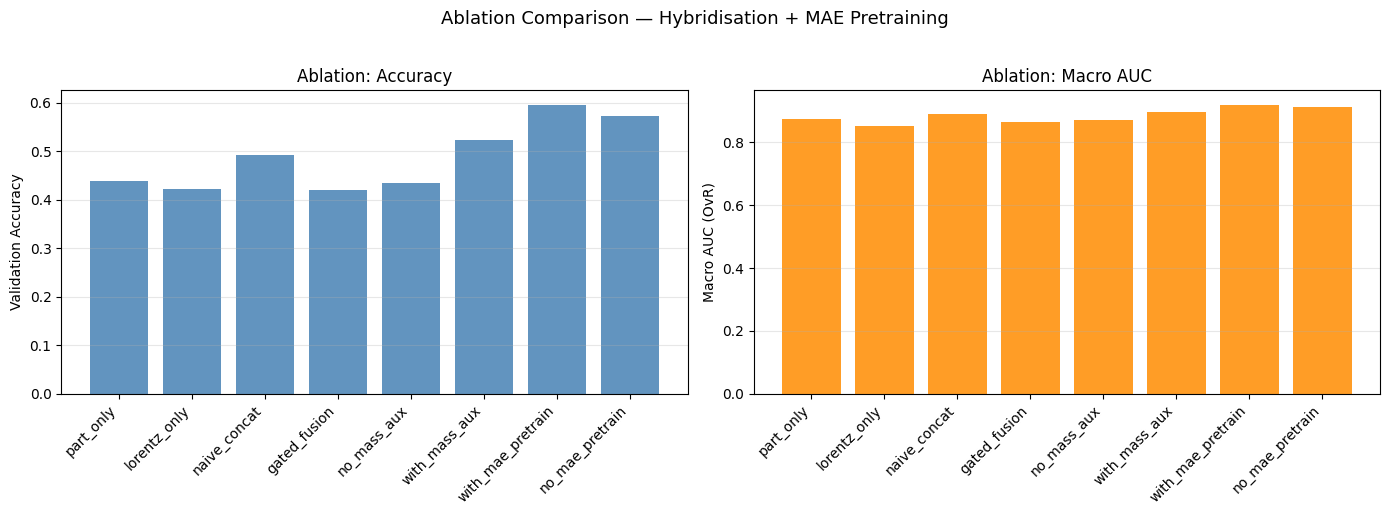

         ablation  train_loss  train_acc  val_acc  val_auc
        part_only    2.035506   0.240863   0.4395 0.874395
     lorentz_only    1.992222   0.259225   0.4225 0.852718
     naive_concat    1.988949   0.258962   0.4922 0.890586
     gated_fusion    2.076113   0.214800   0.4194 0.863528
      no_mass_aux    2.057294   0.223725   0.4347 0.872009
    with_mass_aux    2.024953   0.279700   0.5238 0.896289
with_mae_pretrain         NaN        NaN   0.5961 0.919528
  no_mae_pretrain         NaN        NaN   0.5726 0.911468


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                    
axes[0].bar(ablation_all_df['ablation'], ablation_all_df['val_acc'],
            color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(ablation_all_df)))
axes[0].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Ablation: Accuracy')
axes[0].grid(axis='y', alpha=0.3)

               
axes[1].bar(ablation_all_df['ablation'],
            ablation_all_df['val_auc'].fillna(0),
            color='darkorange', alpha=0.85)
axes[1].set_xticks(range(len(ablation_all_df)))
axes[1].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[1].set_ylabel('Macro AUC (OvR)')
axes[1].set_title('Ablation: Macro AUC')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ablation Comparison â€” Hybridisation + MAE Pretraining',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(ablation_all_df.to_string(index=False))


### Multi-seed Evaluation
Results are repeated across multiple random seeds to report mean performance and variability.

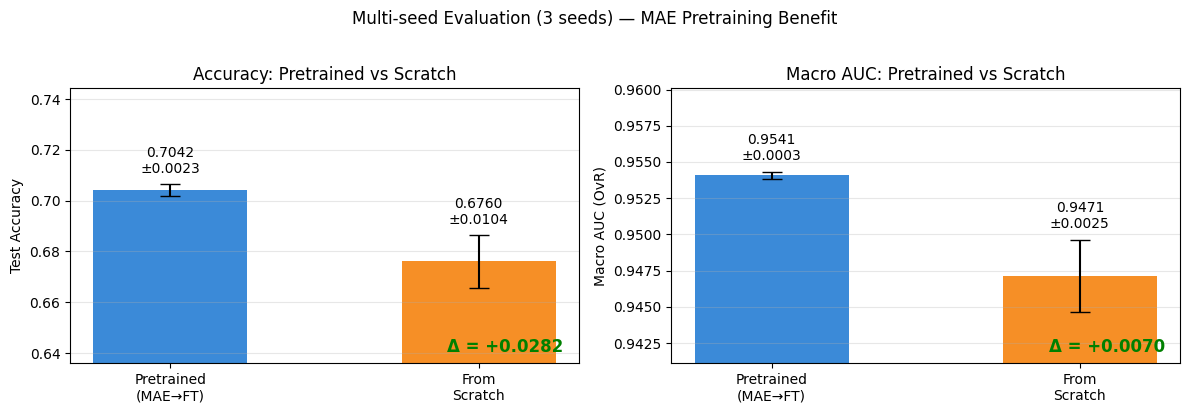

Saved: ./multiseed_comparison.png

MAE pretraining benefit:
  Accuracy  : +0.0282 (4.2% relative)
  AUC       : +0.0070
  Std reduction: 4.5x lower variance with pretraining


In [32]:
                                                                                                                                                               
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modes  = ['Pretrained\n(MAEâ†’FT)', 'From\nScratch']
colors = ['#1976D2', '#F57C00']

acc_means = [comparison_df.loc[comparison_df['mode']=='pretrained','acc_mean'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'acc_mean'].values[0]]
acc_stds  = [comparison_df.loc[comparison_df['mode']=='pretrained','acc_std'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'acc_std'].values[0]]
auc_means = [comparison_df.loc[comparison_df['mode']=='pretrained','auc_mean'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'auc_mean'].values[0]]
auc_stds  = [comparison_df.loc[comparison_df['mode']=='pretrained','auc_std'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'auc_std'].values[0]]

bars0 = axes[0].bar(modes, acc_means, yerr=acc_stds, capsize=7,
                    color=colors, alpha=0.85, width=0.5)
axes[0].set_ylabel('Test Accuracy'); axes[0].set_title('Accuracy: Pretrained vs Scratch')
axes[0].set_ylim(min(acc_means)-0.04, max(acc_means)+0.04)
axes[0].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars0, acc_means, acc_stds):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.003,
                 f'{m:.4f}\nÂ±{s:.4f}', ha='center', va='bottom', fontsize=10)
delta_acc = acc_means[0] - acc_means[1]
axes[0].text(0.97, 0.04, f'Î” = +{delta_acc:.4f}', transform=axes[0].transAxes,
             ha='right', fontsize=12, color='green', fontweight='bold')

bars1 = axes[1].bar(modes, auc_means, yerr=auc_stds, capsize=7,
                    color=colors, alpha=0.85, width=0.5)
axes[1].set_ylabel('Macro AUC (OvR)'); axes[1].set_title('Macro AUC: Pretrained vs Scratch')
axes[1].set_ylim(min(auc_means)-0.006, max(auc_means)+0.006)
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars1, auc_means, auc_stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.0006,
                 f'{m:.4f}\nÂ±{s:.4f}', ha='center', va='bottom', fontsize=10)
delta_auc = auc_means[0] - auc_means[1]
axes[1].text(0.97, 0.04, f'Î” = +{delta_auc:.4f}', transform=axes[1].transAxes,
             ha='right', fontsize=12, color='green', fontweight='bold')

plt.suptitle(f'Multi-seed Evaluation ({N_SEEDS} seeds) â€” MAE Pretraining Benefit',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('./multiseed_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ./multiseed_comparison.png')
print(f'\nMAE pretraining benefit:')
print(f'  Accuracy  : +{delta_acc:.4f} ({delta_acc/acc_means[1]*100:.1f}% relative)')
print(f'  AUC       : +{delta_auc:.4f}')
std_ratio = acc_stds[1] / max(acc_stds[0], 1e-9)
print(f'  Std reduction: {std_ratio:.1f}x lower variance with pretraining')


Event gate summary:
 count    384.000000
mean       0.503979
std        0.035229
min        0.381651
25%        0.485915
50%        0.500002
75%        0.517886
max        0.674293
dtype: float64
Token gate summary:
 count    384.000000
mean       0.397639
std        0.034383
min        0.309616
25%        0.371197
50%        0.396352
75%        0.426278
max        0.485260
dtype: float64


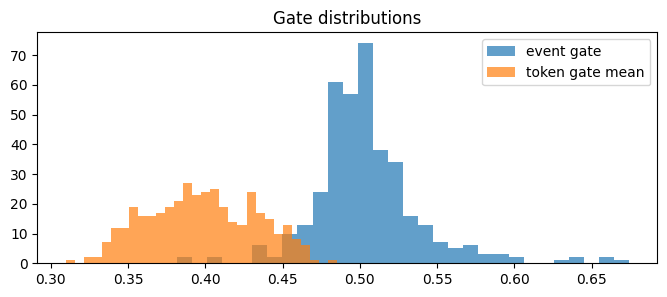

Mean gate by class:
   event_gate  token_gate
y                        
0    0.488484    0.384169
1    0.497802    0.398775
2    0.498196    0.359636
3    0.500788    0.423921
4    0.501691    0.373129
5    0.500146    0.400934
6    0.532227    0.429831
7    0.492351    0.402068
8    0.519998    0.384537
9    0.498467    0.398445


In [33]:
@torch.no_grad()
def inspect_gates(model, loader, n_batches=3):
    model.eval()
    ge, gt, yy = [], [], []
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        batch = to_device(batch, device)
        out = model(batch['x'], batch['p4'], batch['mask'], mode='finetune')
        ge.append(out['g_evt'].squeeze(-1).cpu().numpy())
        gt.append(out['g_tok'].mean(dim=(1,2)).cpu().numpy())
        yy.append(batch['y'].cpu().numpy())

    ge = np.concatenate(ge); gt = np.concatenate(gt); yy = np.concatenate(yy)
    print('Event gate summary:\n', pd.Series(ge).describe())
    print('Token gate summary:\n', pd.Series(gt).describe())

    plt.figure(figsize=(8,3))
    plt.hist(ge, bins=30, alpha=0.7, label='event gate')
    plt.hist(gt, bins=30, alpha=0.7, label='token gate mean')
    plt.legend(); plt.title('Gate distributions'); plt.show()

    df = pd.DataFrame({'y': yy, 'event_gate': ge, 'token_gate': gt})
    print('Mean gate by class:')
    print(df.groupby('y')[['event_gate','token_gate']].mean())

inspect_gates(ft_model, test_loader)


count    4.673000e+03
mean     1.809039e-04
std      2.943852e-04
min      3.901154e-07
25%      1.729653e-05
50%      7.414367e-05
75%      2.287220e-04
max      6.079675e-03
dtype: float64


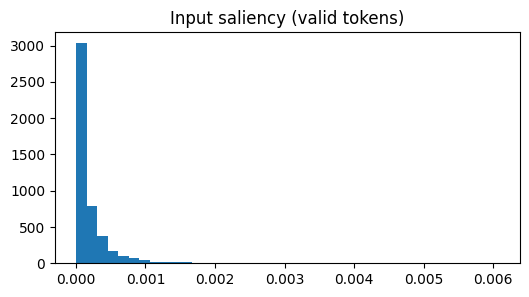

In [ ]:
def simple_saliency(model, batch):
    model.eval()
    x = batch['x'].to(device).clone().detach().requires_grad_(True)
    p4, mask, y = batch['p4'].to(device), batch['mask'].to(device), batch['y'].to(device)

    out = model(x, p4, mask, mode='finetune')
    loss = F.cross_entropy(out['logits'], y)
    loss.backward()

    sal = x.grad.abs().mean(dim=-1).detach().cpu().numpy()
    vm = batch['mask'].numpy() > 0.5
    vals = sal[vm]
    print(pd.Series(vals).describe())
    plt.figure(figsize=(6,3)); plt.hist(vals, bins=40)
    plt.title('Input saliency (valid tokens)'); plt.show()

batch0 = next(iter(test_loader))
simple_saliency(ft_model, batch0)


## 14b. Mass Regression Results
When enabled, the auxiliary head predicts jet invariant mass alongside class labels.
This section summarizes the multi-task behavior and its effect on classification.

In [35]:
print(json.dumps(asdict(cfg), indent=2))

{
  "DATA_ROOT": "C:\\Users\\Rahul\\Desktop\\AA Gsoc'26 p-3\\datasets\\JetClass",
  "MAX_PARTICLES": 50,
  "NUM_CLASSES": 10,
  "BATCH_SIZE": 128,
  "NUM_WORKERS": 0,
  "PRETRAIN_EPOCHS": 20,
  "FINETUNE_EPOCHS": 35,
  "LEARNING_RATE": 0.0003,
  "WEIGHT_DECAY": 0.01,
  "MASK_RATIO": 0.4,
  "WARMUP_EPOCHS": 3,
  "LABEL_SMOOTHING": 0.1,
  "USE_BIASED_MASK": true,
  "BACKBONE_LR_FACTOR": 0.3,
  "KINEMATIC_LOG_FEATURES": [
    "px",
    "py",
    "pz",
    "E",
    "pt",
    "deltaR"
  ],
  "MASS_TARGET_NORMALIZE": true,
  "MASS_NORM_EPS": 1e-06,
  "GATE_REG_WEIGHT": 0.02,
  "USE_JEPA_PRETRAIN": false,
  "JEPA_WEIGHT": 0.5,
  "JEPA_EMA_DECAY": 0.996,
  "ATTN_INTERACTION_GATE_STRENGTH": 1.0,
  "USE_PHYSICS_RECO_WEIGHTING": true,
  "RECO_WEIGHT_PT": 1.0,
  "RECO_WEIGHT_ETA": 0.5,
  "RECO_WEIGHT_PHI": 0.3,
  "RECO_WEIGHT_E": 1.0,
  "RECO_WEIGHT_DEFAULT": 0.7,
  "USE_AUX_MASS": false,
  "USE_CLASS_WEIGHTS": true,
  "USE_MIXED_PRECISION": true,
  "QUICK_DEMO_MODE": false,
  "QUICK_MAX_EVENTS_PE